# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from joblib import Parallel, delayed

from rdkit import Chem
from sklearn.manifold import TSNE
from modules.knn import compute_knn_distance
from modules.qspr_xgb import XGBoostModel

# Visualize the molecules
from chemFilters.img_render import MolGridPlotter

# QSPRpred related imports
from qsprpred.data import MoleculeTable, QSPRDataset
from qsprpred.data.descriptors.fingerprints import MorganFP, RDKitFP

Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


Functions used in the notebook

In [3]:
def read_and_assign_pchembl_vals(dataframe_path, show_plot=False):
    df = pd.read_csv(dataframe_path)
    df["pchembl_value_median"] = df["pchembl_value_median"].fillna(df["pchembl_value"]).astype(float)
    if show_plot:
        df.pchembl_value_median.plot.density(figsize=(6, 2))
        df.pchembl_value_median.isna().sum()
    return df

Paths to the data used in this notebook

In [4]:
model_data_root = Path("../data/virtual_screening/modeling").resolve()
assert model_data_root.exists()

vs_data_root = Path("../data/virtual_screening/vs_datasets").resolve()
assert vs_data_root.exists()

# Load data

## Training data

In [5]:
nr3c2_df = read_and_assign_pchembl_vals(model_data_root / "NR3C2_assayBF_KiIC50_confidence789.csv")
adora1_df = read_and_assign_pchembl_vals(model_data_root / "ADORA1_assayB_Ki_confidence89.csv")

nr3c2_data = QSPRDataset(
    store_dir="qsprData",
    df=nr3c2_df,
    name="NR3C2_IC50Ki",
    target_props=[{"name": "pchembl_value_median", "task": "REGRESSION"}],
    smiles_col="smiles",
    random_state=42,
    overwrite=True,
    n_jobs=4,
)

adora1_data = QSPRDataset(
    store_dir="qsprData",
    df=adora1_df,
    name="ADORA1_Ki",
    target_props=[{"name": "pchembl_value_median", "task": "REGRESSION"}],
    smiles_col="smiles",
    random_state=42,
    overwrite=True,
    n_jobs=4,
)

rdkit_1024fp = RDKitFP(nBits=1024)
ecfp6_1024_fp = MorganFP(radius=3, nBits=1024)
descriptors = [ecfp6_1024_fp, rdkit_1024fp]

nr3c2_data.prepareDataset(
    smiles_standardizer=None,
    feature_calculators=descriptors,
    recalculate_features=True,
)
adora1_data.prepareDataset(
    smiles_standardizer=None,
    feature_calculators=descriptors,
    recalculate_features=True,
)

## Screening data

In [6]:
def pick_first_entry(string):
    """smiles also have the identifiers, so we remove"""
    if " " in string:
        return string.split(" ")[0]


screening_df = (
    pd.concat(
        [
            pd.read_csv(vs_data_root / "emolecules_sw_virtual_screening.csv", engine="pyarrow"),
            pd.read_csv(vs_data_root / "enamine_sw_virtual_screening.csv", engine="pyarrow"),
        ],
        ignore_index=True,
    )
    .drop(columns=["atomScore", "atomMap", "qryMappedSmiles", "hitMappedSmiles", "mf"])
    .rename(columns={"moleculeID": "qry_molecule_chembl_id"})
    .assign(hitSmiles=lambda x: x["hitSmiles"].apply(pick_first_entry))
)
screening_df.head(1)

,qrySmiles,hitSmiles,anonIdx,mw,id,qry_molecule_chembl_id,target_id,provider
0,Cc1cc(-c2nnc(N)nc2-c2cc(F)cc(F)c2)cc(C)n1,Cc1cc(cc(n1)Cl)c2nnc(nc2c3ccc(cc3)F)N,B24R3.8425078,315.733,295311285,CHEMBL2024117,ADORA1,emolecules


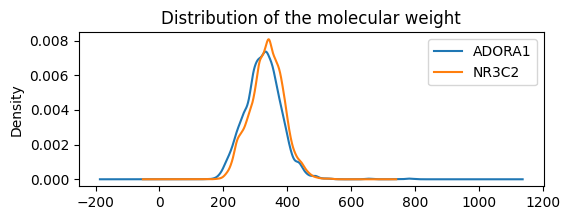

In [7]:
fig, ax = plt.subplots(figsize=(6, 2))
screening_df.groupby("target_id")["mw"].plot.density(ax=ax, legend=True)
ax.set_title("Distribution of the molecular weight")
plt.show()

In [8]:
adora1_moltable = MoleculeTable(
    "VS_set_ADORA1",
    screening_df.query("target_id == 'ADORA1'").reset_index(drop=True),
    smiles_col="hitSmiles",
    n_jobs=4,
)

nr3c2_moltable = MoleculeTable(
    "VS_set_NR3C2",
    screening_df.query("target_id == 'NR3C2'").reset_index(drop=True),
    smiles_col="hitSmiles",
    n_jobs=4,
)

adora1_moltable.addDescriptors(descriptors)
nr3c2_moltable.addDescriptors(descriptors)

qsprpred - WARNING - Dropped 1 invalid molecules from the data set.


### Filter steroids

In [9]:
smarts = "[#6]12-[#6]-[#6]-[#6]3-[#6](-[#6]-1-[#6]-[#6]-[#6]-2)-[#6]-[#6]-[#6]1:,-[#6]-3:,-[#6]:,-[#6]:,-[#6](:,-[#6]:,=1)"

# we don't want have other steroids tested, so we avoid those...
steroid_subset = nr3c2_moltable.searchWithSMARTS(patterns=[smarts], use_chirality=False)
todrop_steroids = steroid_subset.df.index.tolist()

adora1_descriptors = adora1_moltable.getDescriptors()
adora1_smiles = adora1_moltable.df["hitSmiles"]
np.testing.assert_array_equal(adora1_smiles.index, adora1_descriptors.index)

nr3c2_descriptors = nr3c2_moltable.getDescriptors().drop(index=todrop_steroids)
nr3c2_smiles = nr3c2_moltable.df.query("~(index in @todrop_steroids)")["hitSmiles"]
np.testing.assert_array_equal(nr3c2_smiles.index, nr3c2_descriptors.index)

adora1_smiles = adora1_smiles.tolist()
nr3c2_smiles = nr3c2_smiles.tolist()

# Nearest Neighbors

In [10]:
adora1_dist, adora1_idxs = compute_knn_distance(
    adora1_data.getDescriptors().values,
    adora1_descriptors.values,
    dist_metric="jaccard",
    k=10,
    n_jobs=6,
)

nr3c2_dist, nr3c2_idxs = compute_knn_distance(
    nr3c2_data.getDescriptors().values,
    nr3c2_descriptors.values,
    dist_metric="jaccard",
    k=10,
    n_jobs=6,
)

# Virtual screening

## Load the models

In [ ]:
adora1model = XGBoostModel.fromFile("qsprModels/optADORA1_allData/optADORA1_allData/optADORA1_allData_meta.json")

adora1model.estimator
# if cuda:3 is not available for you, you can use another...
# adora1model.estimator.device = "cuda:0"

XGBRegressor(base_score='6.6382346E0', booster='gbtree', callbacks=None,
             colsample_bylevel=0.16394472647476643,
             colsample_bynode=0.5511110197446186,
             colsample_bytree=0.749094881382788, device='cuda:3',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.09961014817318213,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints=None, learning_rate=0.04353228471815173,
             max_bin=256, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=1.2984155166517595, max_depth=12, max_leaves=8495,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=835, n_jobs=8,
             num_parallel_tree=None, random_state=42, ...)

In [12]:
nr3c2model = XGBoostModel.fromFile("qsprModels/optNR3C2_allData/optNR3C2_allData/optNR3C2_allData_meta.json")

nr3c2model.estimator

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=0.6960120254928088,
             colsample_bynode=0.6103975013076565,
             colsample_bytree=0.45592776897290105, device='cuda:0',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.9360243942808202,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints=None, learning_rate=0.07334275253906102,
             max_bin=256, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=2.7034266611335194, max_depth=7, max_leaves=2766,
             min_child_weight=7, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1398, n_jobs=1,
             num_parallel_tree=None, random_state=42, ...)

## Evaluate the molecules

In [13]:
print("descriptors shape:", adora1_descriptors.shape)
print("nn distances shape:", adora1_dist.shape)

descriptors shape: (21217, 2048)
nn distances shape: (21217, 10)


In [14]:
adora1_dist.max(axis=1).ravel()
adora1_dist.min(axis=1).ravel()
adora1_dist.mean(axis=1).ravel()
adora1_dist.sum(axis=1).ravel()

array([1.14105461, 1.59651503, 2.13153606, ..., 1.72931125, 1.74824034,
       1.62266117])

In [15]:
# create the the data to be plotted
screened_adora1_df = adora1_moltable.df.copy().assign(
    predictions=adora1model.estimator.predict(adora1_descriptors.values),
    nn_max=adora1_dist.max(axis=1).ravel(),
    nn_min=adora1_dist.min(axis=1).ravel(),
    nn_mean=adora1_dist.mean(axis=1).ravel(),
    nn_sum=adora1_dist.sum(axis=1).ravel(),
)

screened_nr3c2_df = (
    nr3c2_moltable.df.query("~(index in @todrop_steroids)")
    .copy()
    .assign(
        predictions=nr3c2model.estimator.predict(nr3c2_descriptors.values),
        nn_max=nr3c2_dist.max(axis=1).ravel(),
        nn_min=nr3c2_dist.min(axis=1).ravel(),
        nn_mean=nr3c2_dist.mean(axis=1).ravel(),
        nn_sum=nr3c2_dist.sum(axis=1).ravel(),
    )
)

/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [11:21:42] WARNING: /workspace/src/common/error_msg.cc:33: You have manually specified the `updater` parameter. The `tree_method` parameter will be ignored. Incorrect sequence of updaters will produce undefined behavior. For common uses, we recommend using `tree_method` parameter instead.
  warnings.warn(smsg, UserWarning)
/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [11:21:43] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:3, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg

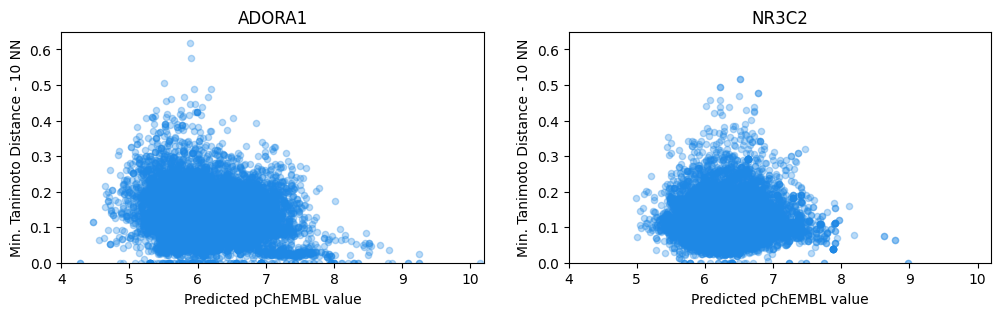

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

screened_adora1_df.plot.scatter(x="predictions", y="nn_min", alpha=0.3, ax=axs[0], color="#1E88E5")
screened_nr3c2_df.plot.scatter(x="predictions", y="nn_min", alpha=0.3, ax=axs[1], color="#1E88E5")

axs[0].set_ylim(0, 0.65)
axs[0].set_xlim(4, 10.2)
axs[0].set_title("ADORA1")
axs[0].set_ylabel("Min. Tanimoto Distance - 10 NN")
axs[0].set_xlabel("Predicted pXC50 value")
axs[0].set_xlabel("Predicted pChEMBL value")

axs[1].set_ylim(0, 0.65)
axs[1].set_xlim(4, 10.2)
axs[1].set_title("NR3C2")
axs[1].set_ylabel("Min. Tanimoto Distance - 10 NN")
axs[1].set_xlabel("Predicted pXC50 value")
axs[1].set_xlabel("Predicted pChEMBL value")

fig.savefig(
    "../figures/ADORA1_NR3C2_predictions_vs_nn_min_distance.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

In [17]:
def smiles_to_chiral_centers(smi):
    """take SMILES string as an input and returns the n chiral centers"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))


def smiles_to_logp(smi):
    """take SMILES string as an input and returns the logP value"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.Crippen.MolLogP(mol)


def smiles_to_lipinski_violations(smi):
    """take SMILES string as an input and returns the n violations of the Lipinski rule"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return sum(
        [
            Chem.Crippen.MolLogP(mol) > 5,
            Chem.Crippen.MolLogP(mol) < -0.4,
            Chem.Descriptors.ExactMolWt(mol) > 500,
            Chem.Descriptors.NumHAcceptors(mol) > 10,
            Chem.Descriptors.NumHDonors(mol) > 5,
        ]
    )


screened_adora1_df = screened_adora1_df.assign(
    n_chiral_centers=Parallel(n_jobs=6)(delayed(smiles_to_chiral_centers)(smi) for smi in adora1_smiles),
    logP=Parallel(n_jobs=6)(delayed(smiles_to_logp)(smi) for smi in adora1_smiles),
    lipinski_violations=Parallel(n_jobs=6)(
        delayed(smiles_to_lipinski_violations)(smi) for smi in adora1_smiles
    ),
)
screened_nr3c2_df = screened_nr3c2_df.assign(
    n_chiral_centers=Parallel(n_jobs=6)(delayed(smiles_to_chiral_centers)(smi) for smi in nr3c2_smiles),
    logP=Parallel(n_jobs=6)(delayed(smiles_to_logp)(smi) for smi in nr3c2_smiles),
    lipinski_violations=Parallel(n_jobs=6)(
        delayed(smiles_to_lipinski_violations)(smi) for smi in nr3c2_smiles
    ),
)

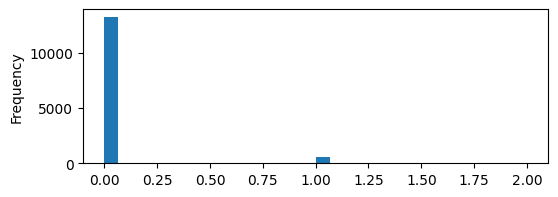

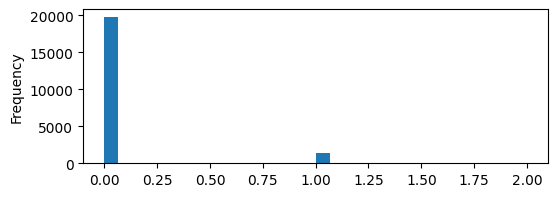

In [18]:
screened_nr3c2_df.lipinski_violations.plot.hist(figsize=(6, 2), bins=30)
plt.show()
screened_adora1_df.lipinski_violations.plot.hist(figsize=(6, 2), bins=30)
plt.show()

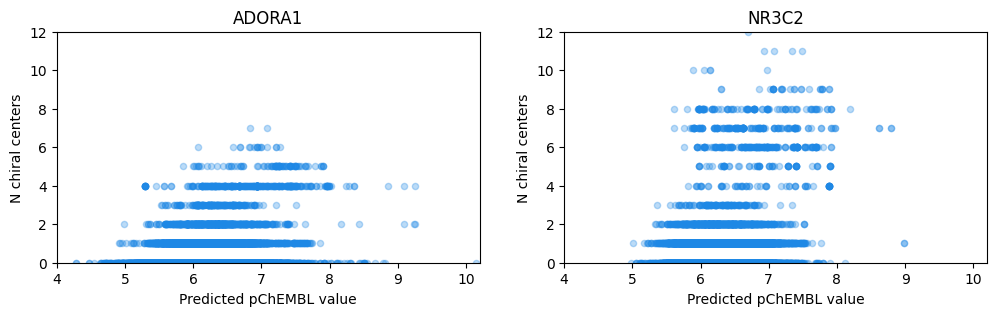

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3))
screened_adora1_df.plot.scatter(x="predictions", y="n_chiral_centers", alpha=0.3, ax=axs[0], color="#1E88E5")
screened_nr3c2_df.plot.scatter(x="predictions", y="n_chiral_centers", alpha=0.3, ax=axs[1], color="#1E88E5")

axs[0].set_ylim(0, 12)
axs[0].set_xlim(4, 10.2)
axs[0].set_title("ADORA1")
axs[0].set_ylabel("N chiral centers")
axs[0].set_xlabel("Predicted pChEMBL value")

axs[1].set_ylim(0, 12)
axs[1].set_xlim(4, 10.2)
axs[1].set_title("NR3C2")
axs[1].set_ylabel("N chiral centers")
axs[1].set_xlabel("Predicted pChEMBL value")

fig.savefig(
    "../figures/ADORA1_NR3C2_predictions_vs_chiralcenters.png", dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

### save the results

In [20]:
# 34
# 472
# 468
# 465
# 462
# 657
# Chem.MolFromSmiles(train_smiles_adora1[465])

In [21]:
train_smiles_adora1 = adora1_data.df["smiles"].tolist()
screened_adora1_df = screened_adora1_df.assign(
    nn_index=adora1_idxs[:, 0],
    nn_smiles=lambda x: x["nn_index"].apply(lambda idx: train_smiles_adora1[idx]),
)

train_smiles_nr3c2 = nr3c2_data.df["smiles"].tolist()
screened_nr3c2_df = screened_nr3c2_df.assign(
    nn_index=nr3c2_idxs[:, 0],
    nn_smiles=lambda x: x["nn_index"].apply(lambda idx: train_smiles_nr3c2[idx]),
)

In [22]:
screened_adora1_df.to_csv(vs_data_root / "screened_adora1_computed_properties.csv", index=False)
screened_nr3c2_df.to_csv(vs_data_root / "screened_nr3c2_computed_properties.csv", index=False)

# Rank & visualize the molecules

In [23]:
sub_adora1 = screened_adora1_df.query("predictions > 7 & n_chiral_centers < 5 & nn_min > 0.04 & nn_min < 0.4")
# for nr3c2 we allow for slightly more similar molecules
sub_nr3c2 = screened_nr3c2_df.query("predictions > 7 & n_chiral_centers < 7 & nn_min > 0.015 & nn_min < 0.4")

subdesc_adora1 = adora1_descriptors.loc[sub_adora1.index]
subdesc_nr3c2 = nr3c2_descriptors.loc[sub_nr3c2.index]


tsne_array = TSNE(
    n_components=2,
    perplexity=50,
    n_iter=5000,
    random_state=42,
    metric="jaccard",
).fit_transform(subdesc_adora1)
sub_adora1 = sub_adora1.assign(tsne1=tsne_array[:, 0], tsne2=tsne_array[:, 1])

tsne_array = TSNE(
    n_components=2,
    perplexity=50,
    n_iter=5000,
    random_state=42,
    metric="jaccard",
).fit_transform(subdesc_nr3c2)
sub_nr3c2 = sub_nr3c2.assign(tsne1=tsne_array[:, 0], tsne2=tsne_array[:, 1])

/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


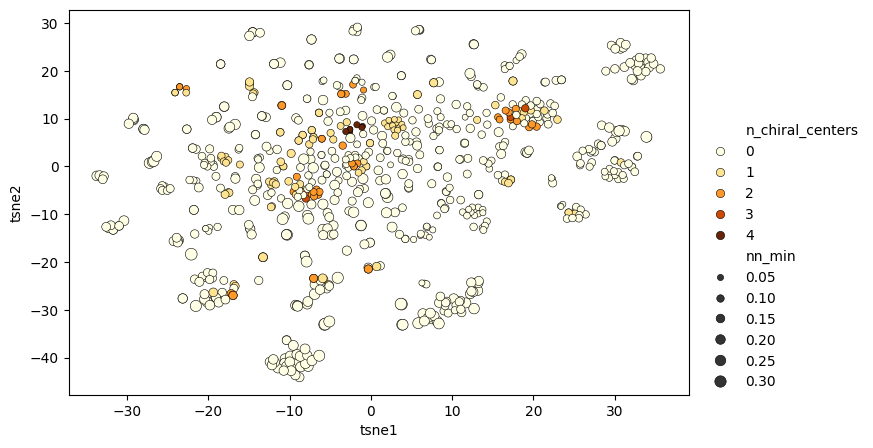

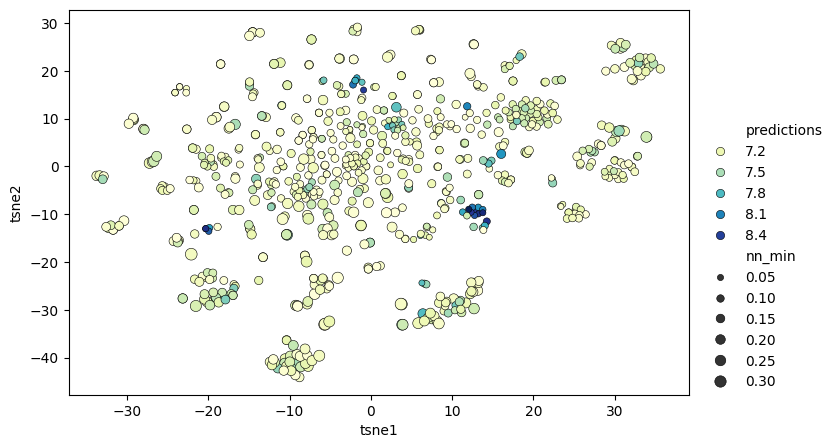

In [24]:
# plot the tsnes for the ADORA1 using a style for the number of chiral centers & size for the nn_min
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sub_adora1,
    x="tsne1",
    y="tsne2",
    hue="n_chiral_centers",
    size="nn_min",
    ax=ax,
    palette="YlOrBr",
    edgecolor="black",
)
ax.legend(bbox_to_anchor=(1.02, 0), loc="lower left", borderaxespad=0, frameon=False)
plt.show()
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sub_adora1,
    x="tsne1",
    y="tsne2",
    hue="predictions",
    size="nn_min",
    ax=ax,
    palette="YlGnBu",
    edgecolor="black",
)
ax.legend(bbox_to_anchor=(1.02, 0), loc="lower left", borderaxespad=0, frameon=False)
plt.show()

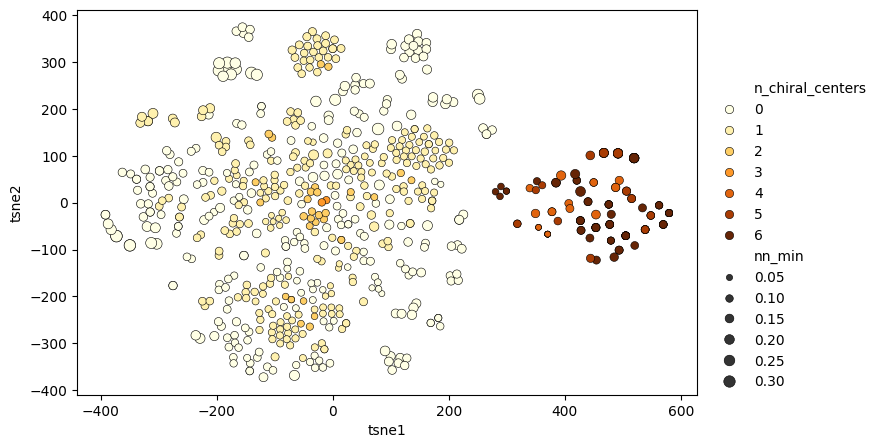

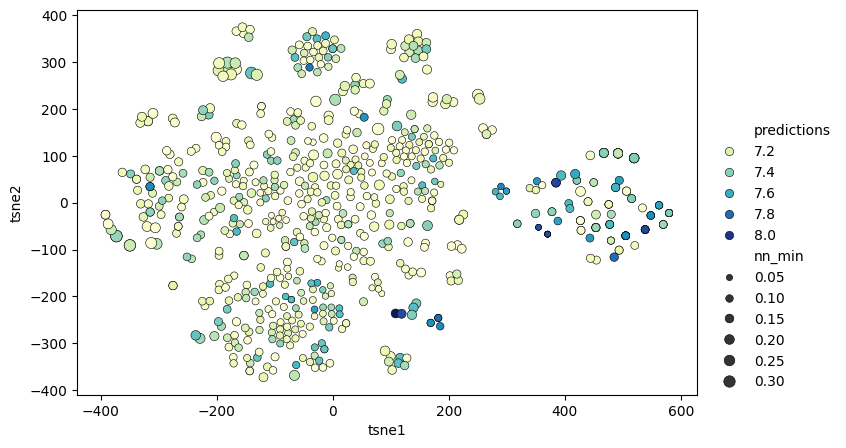

In [25]:
# plot the tsnes for the ADORA1 using a style for the number of chiral centers & size for the nn_min
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sub_nr3c2,
    x="tsne1",
    y="tsne2",
    hue="n_chiral_centers",
    size="nn_min",
    ax=ax,
    palette="YlOrBr",
    edgecolor="black",
)
ax.legend(bbox_to_anchor=(1.02, 0), loc="lower left", borderaxespad=0, frameon=False)
plt.show()
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sub_nr3c2,
    x="tsne1",
    y="tsne2",
    hue="predictions",
    size="nn_min",
    ax=ax,
    palette="YlGnBu",
    edgecolor="black",
)
ax.legend(bbox_to_anchor=(1.02, 0), loc="lower left", borderaxespad=0, frameon=False)
plt.show()

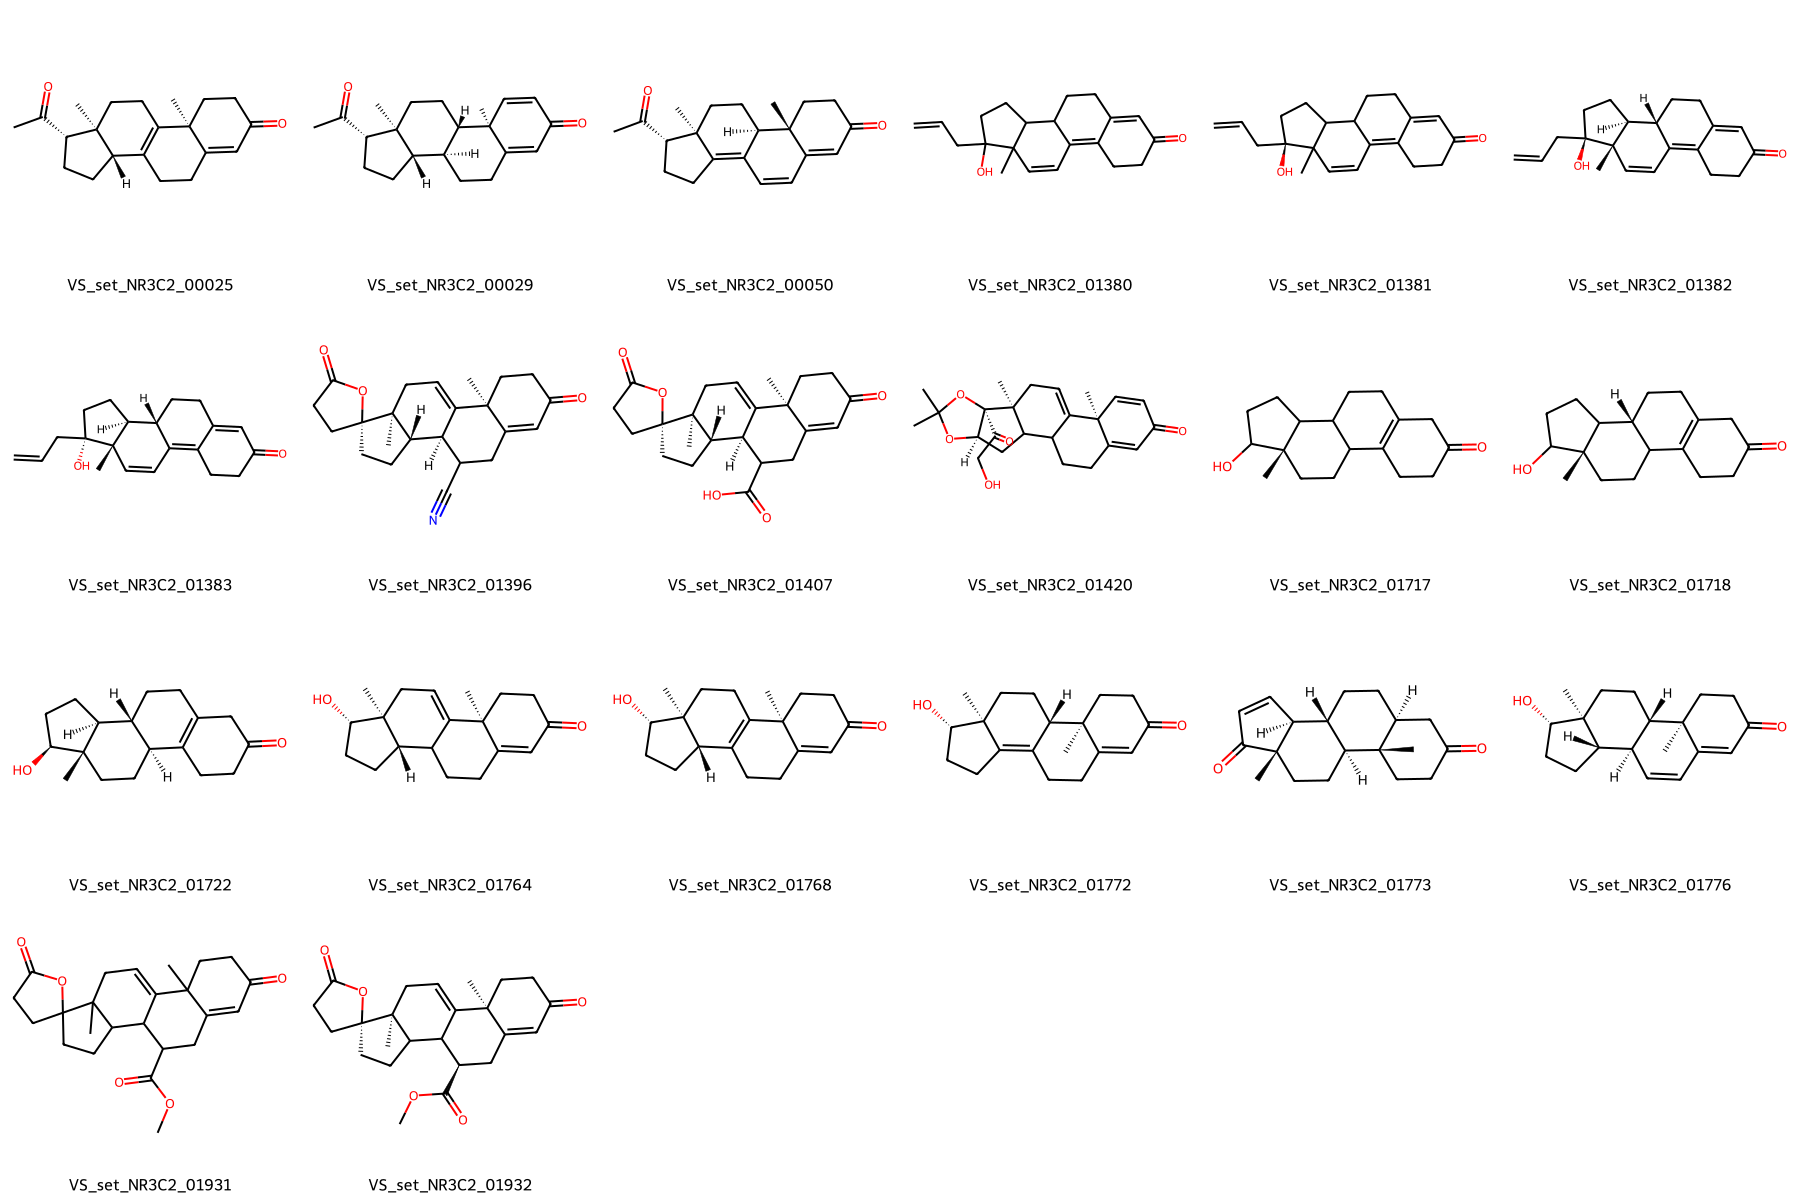

In [26]:
plotter = MolGridPlotter(from_smi=True)

question = sub_nr3c2.query("tsne1 > 200 & tsne2 < 120 & n_chiral_centers > 2")

plotter.mol_grid_png(mols=question["hitSmiles"].tolist()[:20], labels=question.index.tolist()[:20], n_cols=6)

In [27]:
# move them from the dataset...
todrop_idxs = sub_nr3c2.query("tsne1 > 200 & tsne2 < 120 & n_chiral_centers > 2").index.tolist()
sub_nr3c2 = sub_nr3c2.drop(index=todrop_idxs)

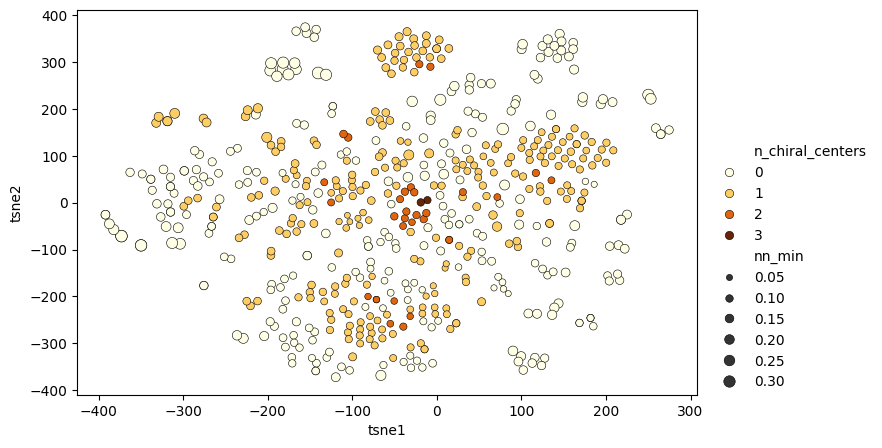

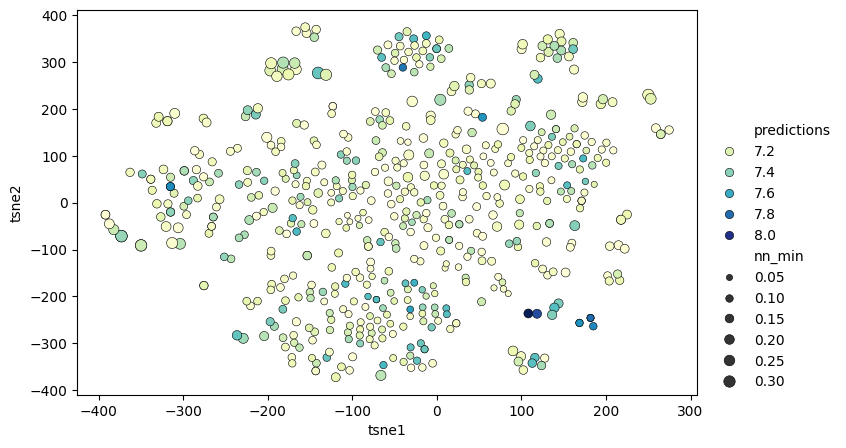

In [28]:
# plot the tsnes for the ADORA1 using a style for the number of chiral centers & size for the nn_min
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sub_nr3c2,
    x="tsne1",
    y="tsne2",
    hue="n_chiral_centers",
    size="nn_min",
    ax=ax,
    palette="YlOrBr",
    edgecolor="black",
)
ax.legend(bbox_to_anchor=(1.02, 0), loc="lower left", borderaxespad=0, frameon=False)
plt.show()
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sub_nr3c2,
    x="tsne1",
    y="tsne2",
    hue="predictions",
    size="nn_min",
    ax=ax,
    palette="YlGnBu",
    edgecolor="black",
)
ax.legend(bbox_to_anchor=(1.02, 0), loc="lower left", borderaxespad=0, frameon=False)
plt.show()

### Save the selection

In [ ]:
sub_adora1.to_csv(vs_data_root / "screened_selected_adora1_cpds.csv")
sub_nr3c2.to_csv(vs_data_root / "screened_selected_nr3c2_cpds.csv")

# Check for in-stock

## load saved data

In [ ]:
sub_adora1 = pd.read_csv(vs_data_root / "screened_selected_adora1_cpds.csv")
sub_nr3c2 = pd.read_csv(vs_data_root / "screened_selected_nr3c2_cpds.csv")

In [31]:
print("adora1 - molecules selected:", len(sub_adora1))
print("    from enamine:", len(sub_adora1.query("provider == 'enamine'")))
print("    from emolecules:", len(sub_adora1.query("provider == 'emolecules'")))
print("nr3c2 - molecules selected:", len(sub_nr3c2))
print("    from enamine:", len(sub_nr3c2.query("provider == 'enamine'")))
print("    from emolecules:", len(sub_nr3c2.query("provider == 'emolecules'")))

adora1 - molecules selected: 790
    from enamine: 378
    from emolecules: 412
nr3c2 - molecules selected: 586
    from enamine: 349
    from emolecules: 237


## ADORA1

### Enamine ids

In [32]:
print("\n".join(sub_adora1.query("provider == 'enamine'").id.tolist()))

Z1169845922
PV-008838423445
Z1197665760
Z2902991454
Z1169897755
Z1169883779
Z1170130193
Z1169935068
Z1169912504
Z1169904754
Z1170213511
Z6311190073
Z1170135797
Z1170061843
Z1682741677
PV-008740819668
PV-007345365785
Z1169847266
Z1169952197
Z1169948421
Z1197799282
Z1082771490
PV-002126767065
Z1169846687
Z1169885058
Z1170214790
Z1170137377
Z1170063315
Z1197781464
Z1682742263
Z2091580551
PV-004521751507
PV-002120079918
Z226588024
Z3484602070
Z2977689758
Z4908094964
Z2861583060
PV-002756809002
Z1567994586
Z1679670872
PV-002965425164
PV-003006699059
PV-005835380241
PV-005310363018
Z2142458702
Z1476770279
Z1567993514
Z1567994648
Z4995167527
PV-002921575059
PV-002711624680
PV-002850626348
Z1476769298
Z1679981463
PV-002836660017
Z1130754666
Z3345522116
Z1567993850
Z1567993620
Z2148314801
Z1567993895
Z1239077504
Z4926772481
PV-006472430577
Z666480484
PV-008175681569
Z1527366172
Z2902654492
Z1745871015
Z1591657520
Z917017418
Z368979830
Z3362180282
Z3651500663
PV-002956369821
PV-006044284889
PV-0

### eMolecules ids

In [33]:
print("\n".join(sub_adora1.query("provider == 'emolecules'").id.astype(str).tolist()))

37034318
37034094
300022029
1062706
37034320
37034090
4493669
1002539
630953
37034106
37033558
37033536
252410060
260931451
324147331
6780871
324649472
324589810
324619784
46581083
37044126
315150957
11476715
31660878
640436
980010
317363491
314717324
233009947
315139674
46050031
32539788
32539956
35775486
4389914
44420586
50421731
184341663
44603904
50426625
6817840
2927031
27495319
43900617
2169189
2076414
4442248
1218887
30411488
530515
532923
1310933
29273220
2075438
4489605
2076163
4476730
1196121
1937097
1681642
6442350
177525236
6157488
2411698
4449535
5868832
1053737
555605
50063137
4493274
25381342
27123718
104427861
2515791
2520056
8674884
33507764
535706
315175185
27500099
315792596
317461347
33296104
23025418
13578784
44856900
1286151
2966955
3746314
3746446
6727387
3746322
3746320
824745
8250492
3746316
1333920
3744460
3749966
5791748
5792014
1308375
1487904
825196
3051209
43921433
16061759
16061761
16061781
16061787
16061783
1973406
37163756
314281513
1249141
36567717
763

## NR3C2

### Enamine ids

In [34]:
print("\n".join(sub_nr3c2.query("provider == 'enamine'").id.tolist()))

Z1966746164
PV-008798314420
PV-008450596620
Z2722989714
PV-008317129425
PV-007996875333
Z64396662
Z821388746
Z64396673
Z927453452
Z136867380
Z64396675
PV-007434072732
PV-007476535606
Z1621037304
Z1621141777
Z1416473021
Z1620527631
Z5189034599
Z234230198
PV-006491923147
Z2295470212
PV-002177567075
Z5024941297
PV-002310865025
Z1224920559
PV-002834079840
PV-002758415099
PV-002883961068
PV-003726634929
Z1275488456
PV-008399564450
Z1305489038
Z1277538988
Z1275487385
Z1582860411
Z2840893772
PV-007257498174
Z2840896525
Z1185716595
Z1187036127
Z1277828016
PV-008067222468
PV-002974954670
PV-002762566932
PV-007828807136
PV-007115608949
PV-006769475035
Z5113032496
PV-006855337478
PV-007445662588
Z6288983972
PV-008205063308
Z5409897164
Z3776880926
PV-006585036301
Z1187967506
Z320039022
Z2991614942
PV-002151998409
Z2991620139
Z1223172734
Z320095076
Z763181716
Z850829096
Z320095110
Z830167170
PV-002903990308
PV-002739647616
PV-002810798318
Z4926123873
PV-006253341206
PV-002851443377
PV-004475575636


### eMolecules ids

In [35]:
print("\n".join(sub_nr3c2.query("provider == 'emolecules'").id.astype(str).tolist()))

32717876
302737365
302721678
2156226
48294548
4802497
317973061
75509390
627919
627911
628139
1207271
1207187
102737713
313795821
7685640
2098304
7865123
184927205
181588927
181588948
181589000
49843283
8202142
26815215
320406982
321329669
1731748
1505887
182601108
43407483
321837277
317674655
40134919
32397004
321534817
321532778
25939426
328668982
328675388
31866782
318719043
318687995
313795821
48556702
324785064
2189366
2147449
301789149
2149134
330311519
323650998
2345864
6765660
2467798
627929
1254592
17398091
1235110
3748054
1224137
30572536
567964
1207271
327098366
3745380
3745182
590314
184572550
184572460
24060840
49843283
24005326
30018876
322762081
4668029
24016994
24005904
31391269
25664777
7455698
49843285
49843281
44061872
322477383
38033035
315213220
315212198
314068385
314190081
28305327
315384475
315560135
41979126
315211689
4711500
180354109
328130957
317674655
1108686
25029823
300764723
7447528
32074486
318149041
320396308
29672942
30549451
2502565
17212324
18904289

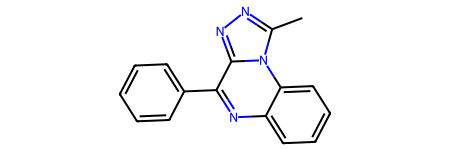

In [36]:
Chem.MolFromSmiles("Cc1nnc2c(nc3ccccc3n12)-c1ccccc1")

# Loading only in-stock

identifiers printed in the cells above were used to search for molecules in each of the provider's respective databases

## ADORA1

In [37]:
emols = pd.read_csv(vs_data_root / "in_stock/eMolecules_adora1_stock.csv", engine="pyarrow")

In [38]:
instock_adora1_emols = (
    emols.rename(columns={"SMILES": "supplier_smiles", "EMOLECULES_ID": "id"})
    .assign(id=lambda x: x["id"].astype(str))
    .drop(
        columns=[
            "MWT",
            "MF",
            "PARENT_MWT",
            "SUPPLIER_NAME",
            "CATALOG_NUMBER",
            "PRICE_CODE",
            "CAS",
            "CHEMICAL_NAME",
            "MFCD",
        ]
    )
    .merge(sub_adora1.assign(id=sub_adora1.id.astype(str)), left_on="id", right_on="id", how="left")
)

In [39]:
enamine = pd.read_csv(vs_data_root / "in_stock/Enamine_adora1_stock.csv", engine="pyarrow", sep=";")

In [40]:
instock_adora1_enamine = (
    enamine.rename(columns={"structure": "supplier_smiles", "CatalogID": "id"})
    .drop(
        columns=[
            "Formula",
            "LOGS",
            "LOGP",
            "Rotating_bonds",
            "HB_acceptors",
            "HB_donors",
            "Purity",
            "Stock_mg",
        ]
    )
    .merge(sub_adora1.assign(id=sub_adora1.id.astype(str)), left_on="id", right_on="id", how="left")
)

In [41]:
instock_adora1 = pd.concat([instock_adora1_emols, instock_adora1_enamine], ignore_index=True).drop_duplicates(
    subset=["supplier_smiles"]
)

In [42]:
instock_adora1.shape

(103, 23)

### MCS-based clustering

To check for the diversity of the _in-stock_ molecules in the virtual screening dataset, we'll use the MCS-based clustering method. For this we'll need to install an extra dependency:
```shell
python -m pip install git+https://github.com/David-Araripe/MolClusterkit.git
```

In [43]:
# !python -m pip install git+https://github.com/David-Araripe/MolClusterkit.git

In [44]:
from MolClusterkit.mcs import MCSClustering

clusterer = MCSClustering(instock_adora1.supplier_smiles.tolist())
clusterer.compute_similarity_matrix()
print("Done!")

100%|██████████| 5253/5253 [00:16<00:00, 326.46it/s] 


Done!


/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


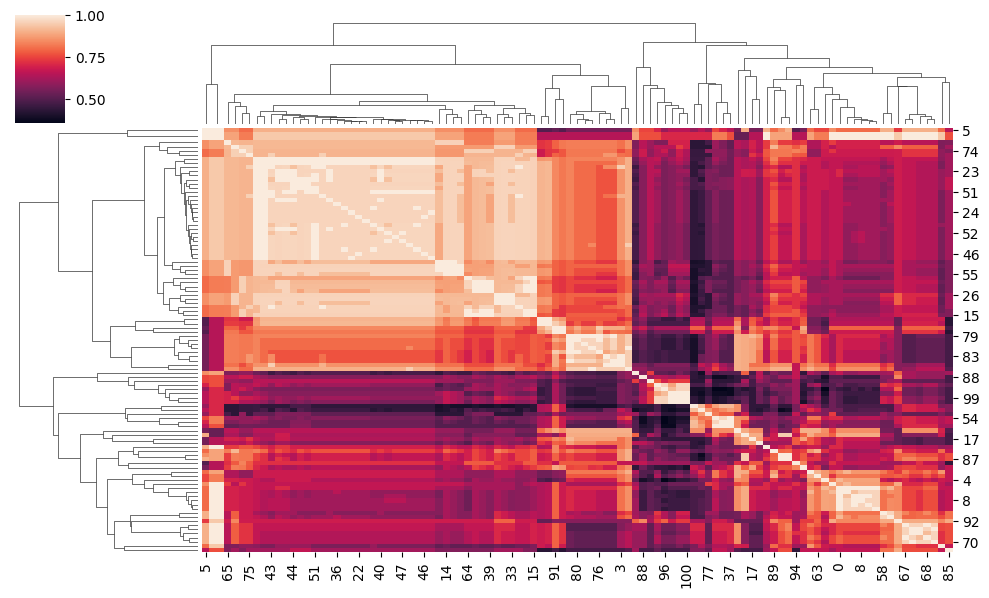

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(clusterer.similarity_matrix, figsize=(10, 6))

### Display molecules & HBA/HBD profile

In [46]:
def smiles_to_hb_acceptors(smi):
    """take SMILES string as an input and returns the number of hydrogen bond acceptors"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.Descriptors.NumHAcceptors(mol)


def smiles_to_hb_donors(smi):
    """take SMILES string as an input and returns the number of hydrogen bond donors"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.Descriptors.NumHDonors(mol)


instock_adora1 = instock_adora1.assign(
    hba=instock_adora1.supplier_smiles.apply(smiles_to_hb_acceptors),
    hbd=instock_adora1.supplier_smiles.apply(smiles_to_hb_donors),
)

cluster: 0 n_molecules: 13


/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/MolClusterkit/mcs.py:200: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method=method)


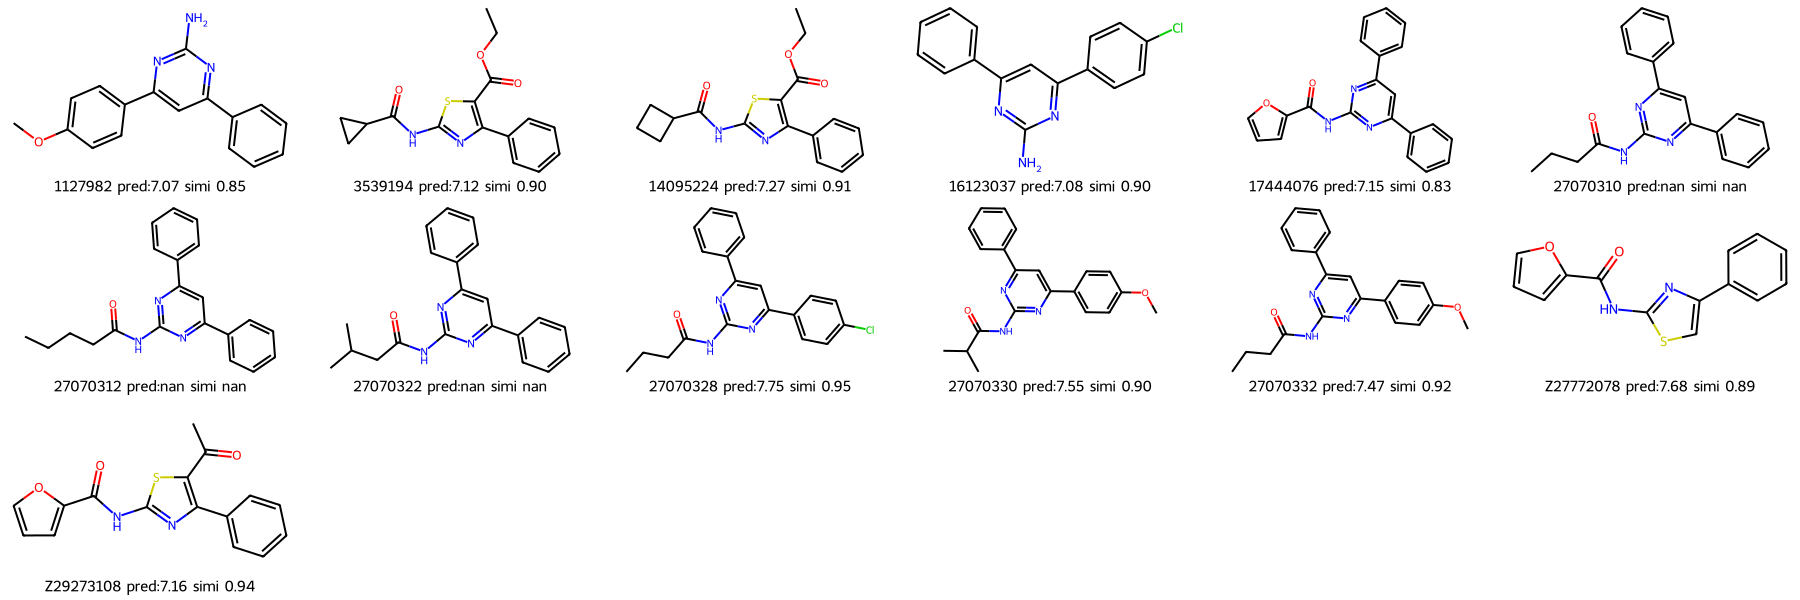

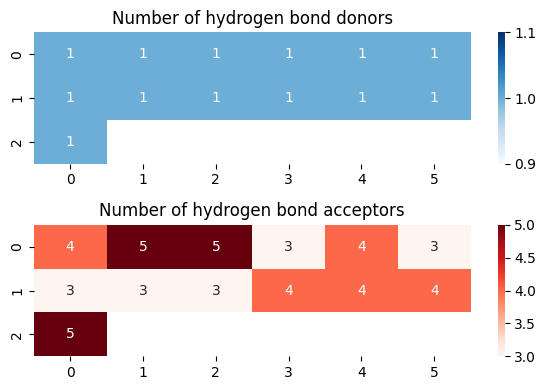

cluster: 1 n_molecules: 3


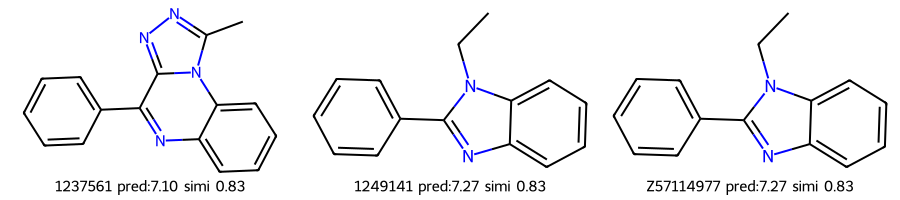

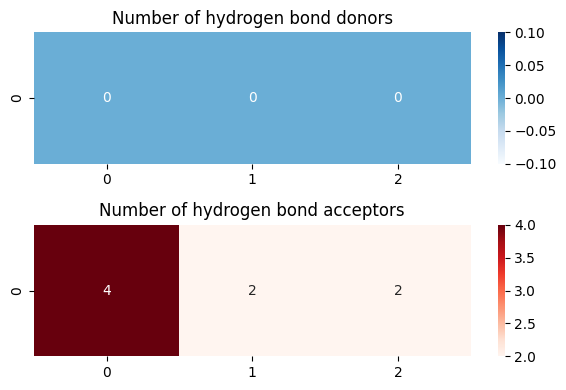

cluster: 2 n_molecules: 43


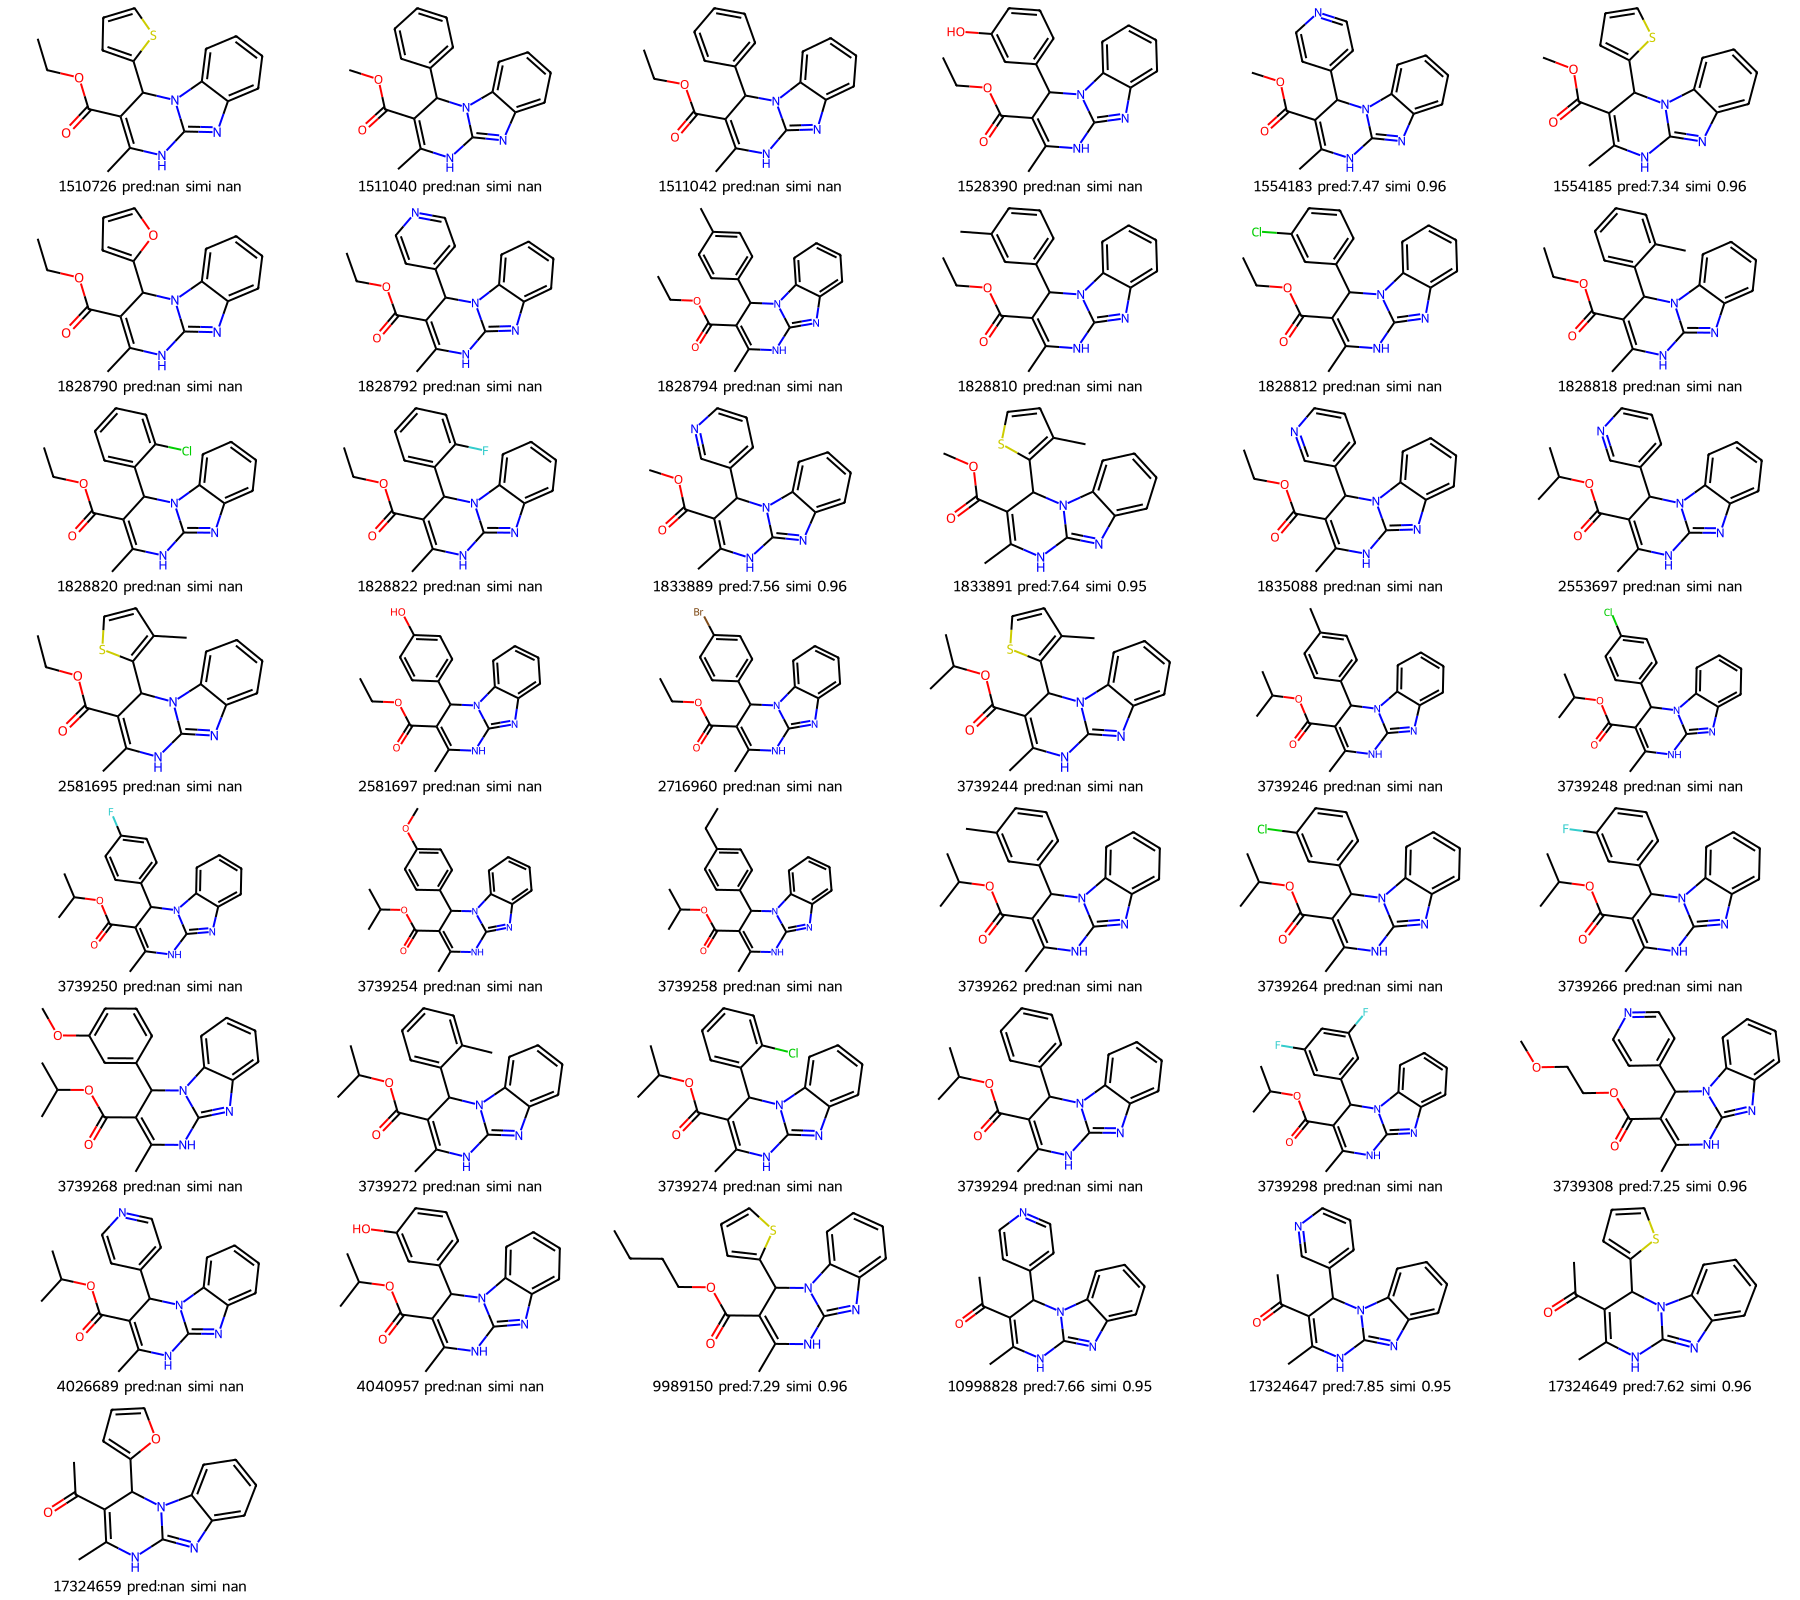

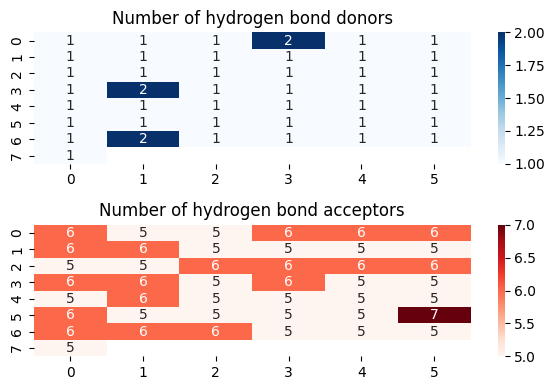

cluster: 3 n_molecules: 11


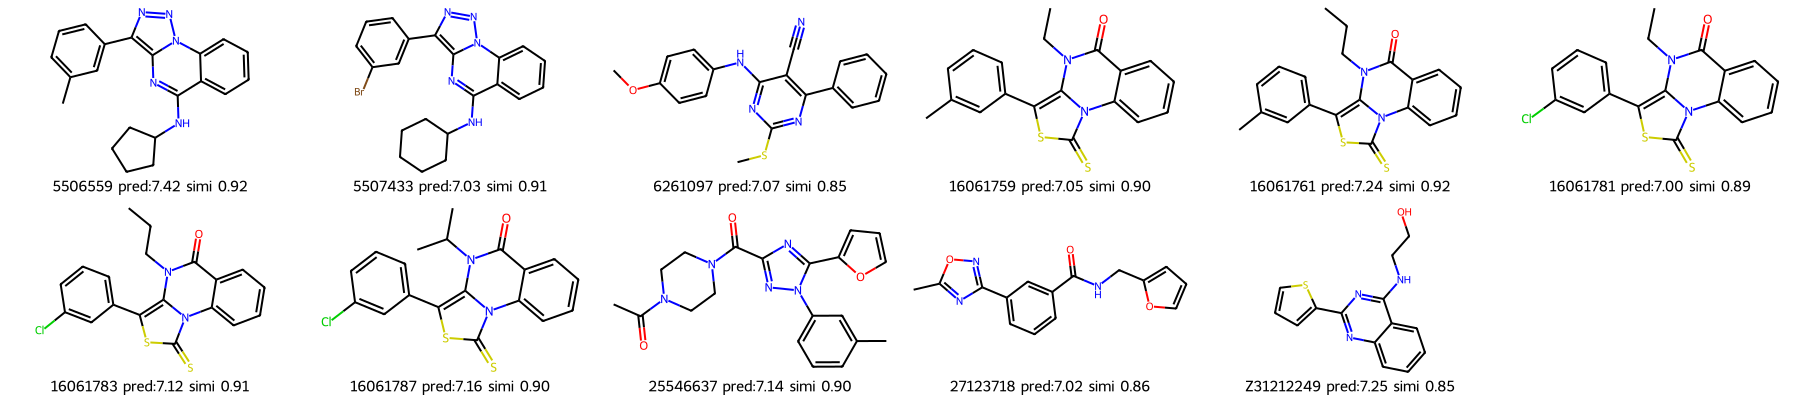

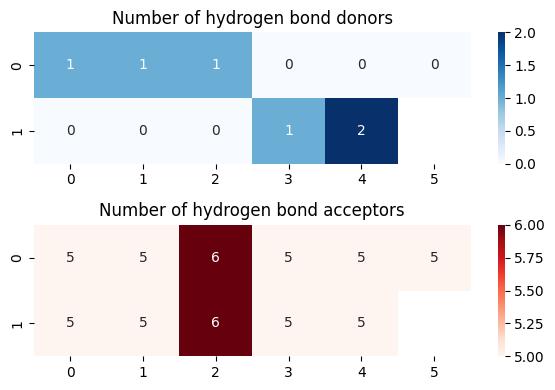

cluster: 4 n_molecules: 20


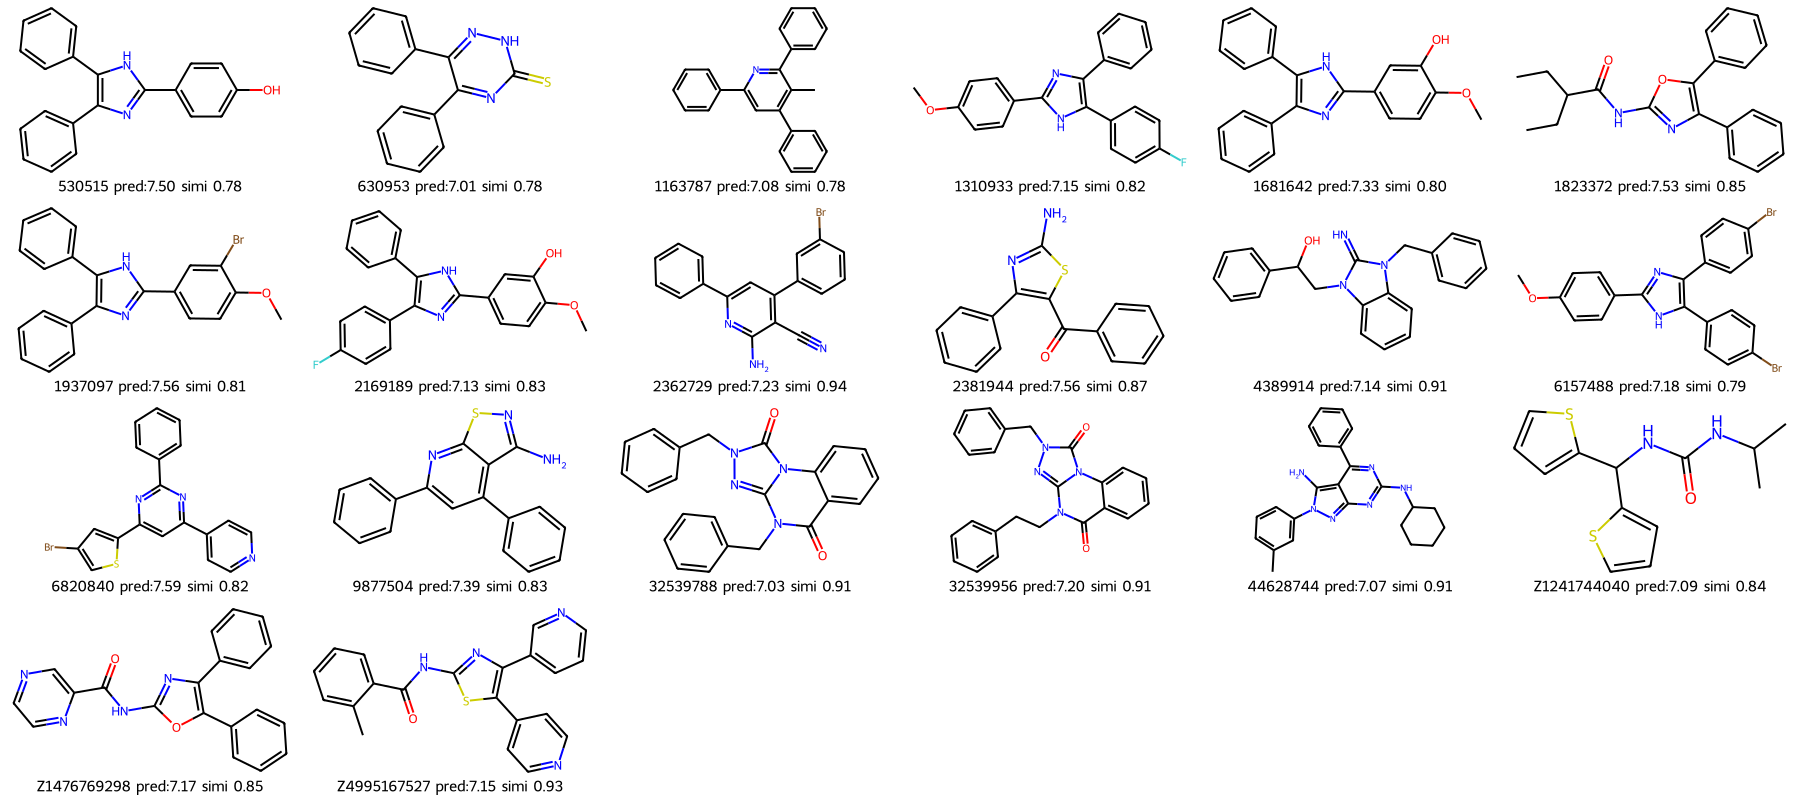

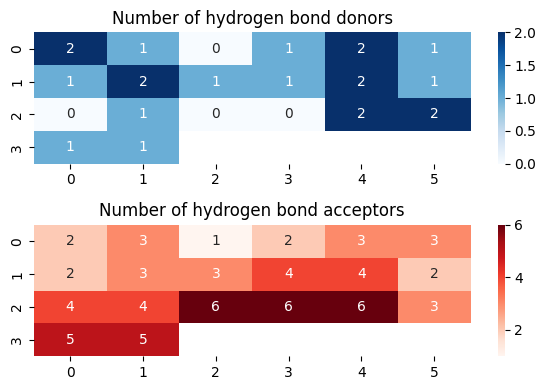

cluster: 5 n_molecules: 7


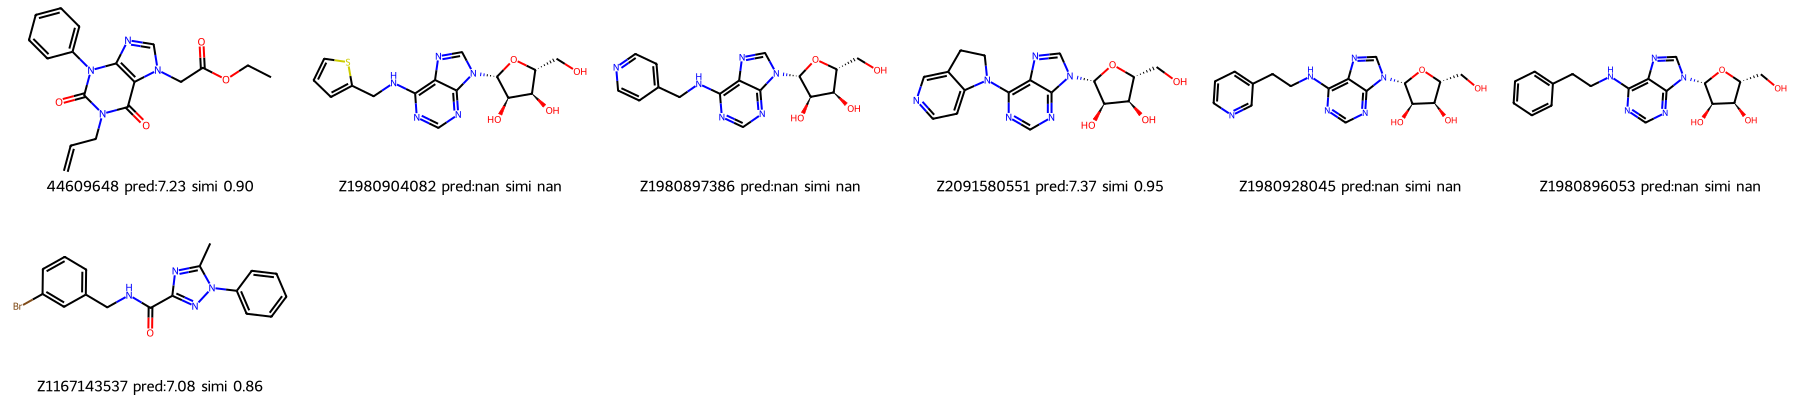

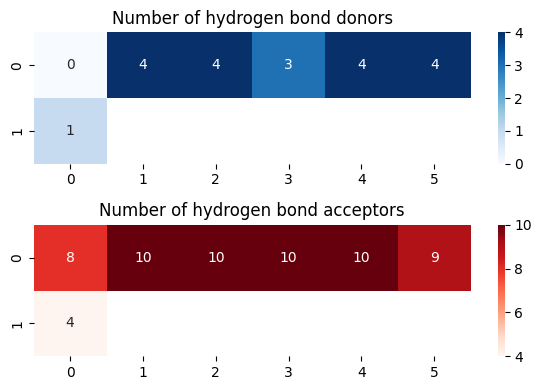

cluster: 6 n_molecules: 6


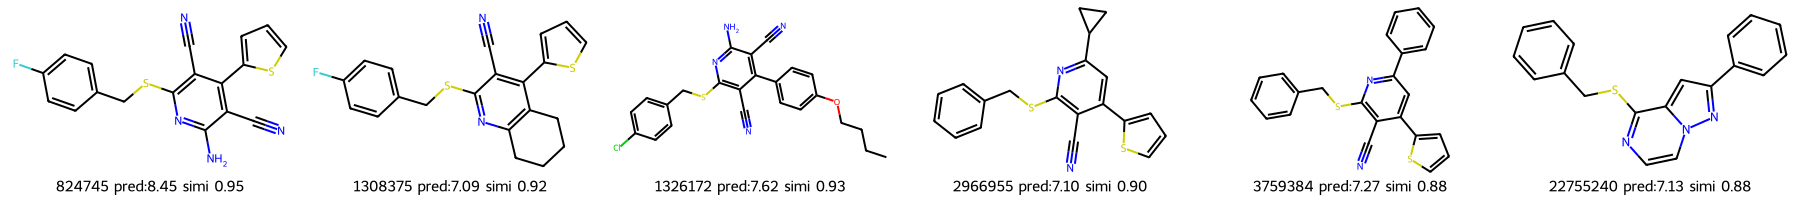

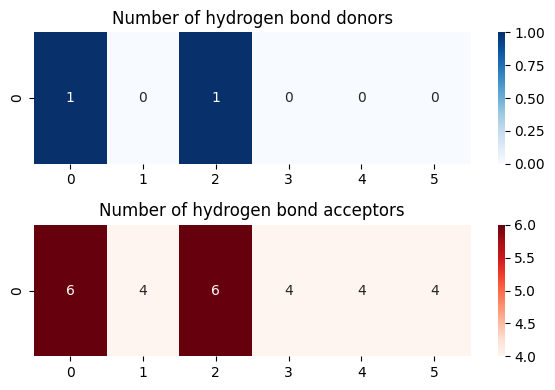

In [47]:
cluster_labels = clusterer.hierarchical_clustering(7, method="ward", criterion="maxclust")

plotter = MolGridPlotter(from_smi=True, size=(300, 200))

ncols = 6
for label in np.unique(cluster_labels):
    idxs = np.where(cluster_labels == label)[0]
    smiles = instock_adora1.supplier_smiles.iloc[idxs].tolist()
    labels = (
        instock_adora1.id.iloc[idxs]
        + " pred:"
        + instock_adora1.predictions.iloc[idxs].apply(lambda x: f"{x:.2f}")
        + " simi "
        + (1 - instock_adora1.nn_min.iloc[idxs]).apply(lambda x: f"{x:.2f}")
    )
    print("cluster:", label, "n_molecules:", len(idxs))
    img = plotter.mol_grid_png(
        mols=smiles,
        labels=labels,
        n_cols=ncols,
    )
    display(img)

    nrows = len(smiles) // ncols + 1 if len(smiles) % ncols != 0 else len(smiles) // ncols
    hbds = instock_adora1.iloc[idxs]["hbd"].tolist()
    hbas = instock_adora1.iloc[idxs]["hba"].tolist()
    if len(smiles) < ncols:
        fill_len = 0
        hbds = np.array(hbds + ([np.nan] * fill_len)).reshape(1, -1)
        hbas = np.array(hbas + ([np.nan] * fill_len)).reshape(1, -1)
    else:
        fill_len = ncols * nrows - len(smiles)
        hbds = np.array(hbds + ([np.nan] * fill_len)).reshape(nrows, ncols)
        hbas = np.array(hbas + ([np.nan] * fill_len)).reshape(nrows, ncols)
    fig, axs = plt.subplots(nrows=2, figsize=(ncols, 4))
    sns.heatmap(hbds, annot=True, ax=axs[0], cmap="Blues")
    axs[0].set_title("Number of hydrogen bond donors")
    sns.heatmap(hbas, annot=True, ax=axs[1], cmap="Reds")
    axs[1].set_title("Number of hydrogen bond acceptors")
    fig.tight_layout()
    plt.show()

## NR3C2

In [48]:
emols = pd.read_csv(vs_data_root / "in_stock/eMolecules_nr3c2_stock.csv", engine="pyarrow")
instock_nr3c2_emols = (
    emols.rename(columns={"SMILES": "supplier_smiles", "EMOLECULES_ID": "id"})
    .assign(id=lambda x: x["id"].astype(str))
    .drop(
        columns=[
            "MWT",
            "MF",
            "PARENT_MWT",
            "SUPPLIER_NAME",
            "CATALOG_NUMBER",
            "PRICE_CODE",
            "CAS",
            "CHEMICAL_NAME",
            "MFCD",
        ]
    )
    .merge(sub_nr3c2.assign(id=sub_nr3c2.id.astype(str)), left_on="id", right_on="id", how="left")
)

enamine = pd.read_csv(vs_data_root / "in_stock/Enamine_nr3c2_stock.csv", engine="pyarrow", sep=";")
instock_nr3c2_enamine = (
    enamine.rename(columns={"structure": "supplier_smiles", "CatalogID": "id"})
    .drop(
        columns=[
            "Formula",
            "LOGS",
            "LOGP",
            "Rotating_bonds",
            "HB_acceptors",
            "HB_donors",
            "Purity",
            "Stock_mg",
        ]
    )
    .merge(sub_nr3c2.assign(id=sub_nr3c2.id.astype(str)), left_on="id", right_on="id", how="left")
)

In [49]:
instock_nr3c2 = pd.concat([instock_nr3c2_emols, instock_nr3c2_enamine], ignore_index=True).drop_duplicates(
    subset=["supplier_smiles"]
)

In [50]:
instock_nr3c2 = instock_nr3c2.query("~supplier_smiles.isna()").reset_index(drop=True)

In [51]:
instock_nr3c2.shape

(73, 28)

### MCS-based clustering

In [52]:
clusterer = MCSClustering(instock_nr3c2.supplier_smiles.tolist())
clusterer.compute_similarity_matrix()
print("Done!")

  0%|          | 0/2628 [00:00<?, ?it/s]

100%|██████████| 2628/2628 [00:02<00:00, 1306.27it/s]


Done!


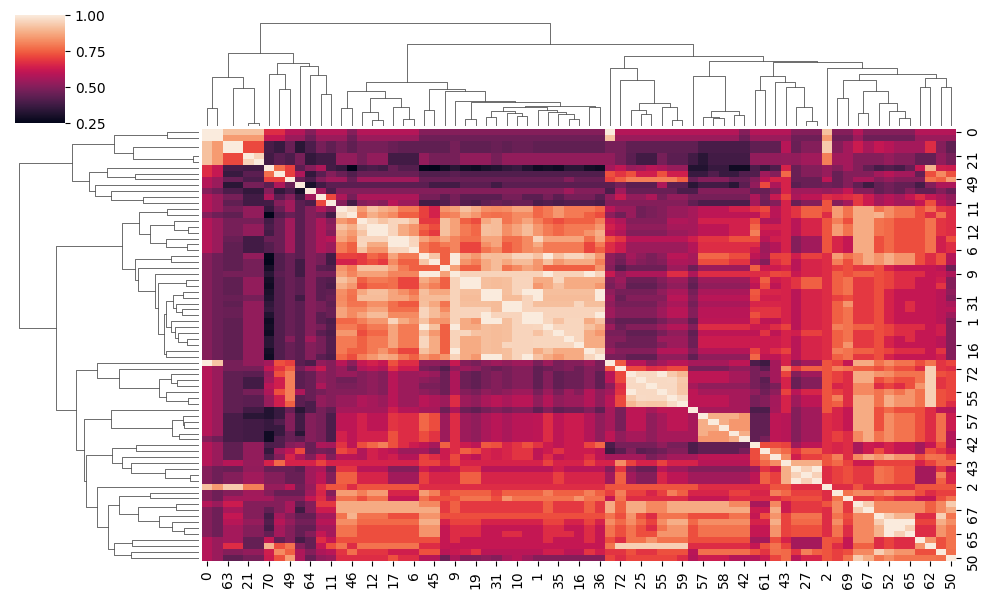

In [53]:
sns.clustermap(clusterer.similarity_matrix, figsize=(10, 6))

### Display molecules & HBA/HBD profile

In [54]:
# make a function that returns the number of hydrogen bond acceptors
def smiles_to_hb_acceptors(smi):
    """take SMILES string as an input and returns the number of hydrogen bond acceptors"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.Descriptors.NumHAcceptors(mol)


def smiles_to_hb_donors(smi):
    """take SMILES string as an input and returns the number of hydrogen bond acceptors"""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.Descriptors.NumHDonors(mol)


instock_nr3c2 = instock_nr3c2.assign(
    hba=instock_nr3c2.supplier_smiles.apply(smiles_to_hb_acceptors),
    hbd=instock_nr3c2.supplier_smiles.apply(smiles_to_hb_donors),
)

cluster: 0 n_molecules: 26


/home/david/micromamba/envs/cystToTarget/lib/python3.10/site-packages/MolClusterkit/mcs.py:200: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method=method)


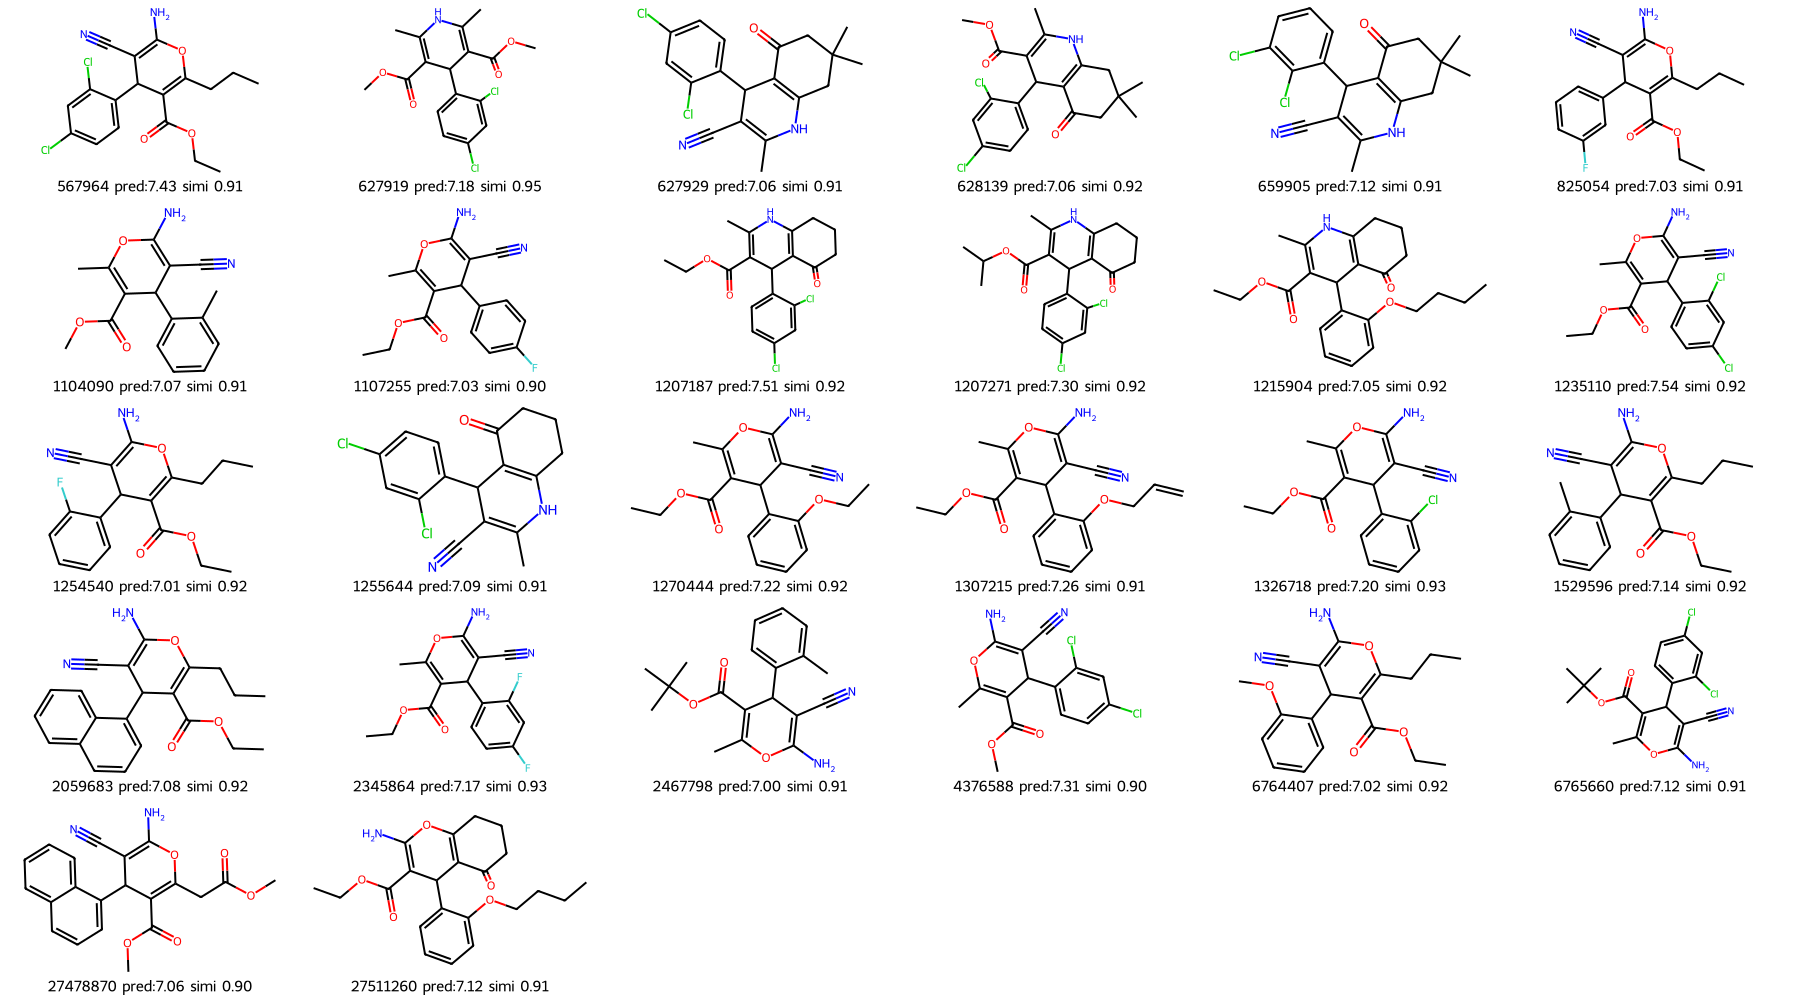

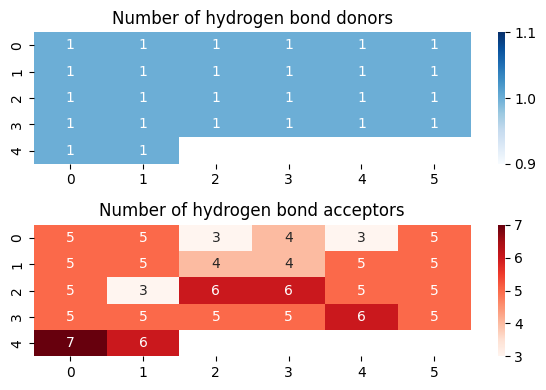

cluster: 1 n_molecules: 6


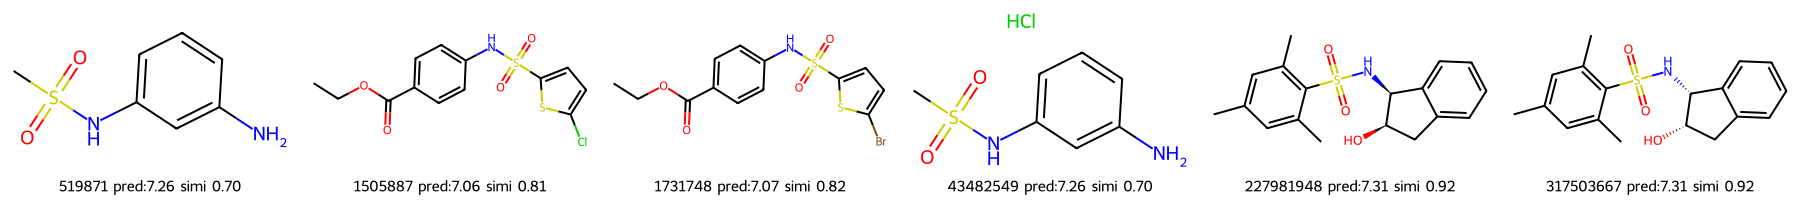

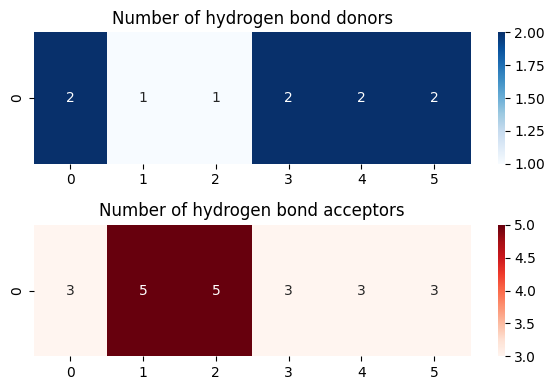

cluster: 2 n_molecules: 7


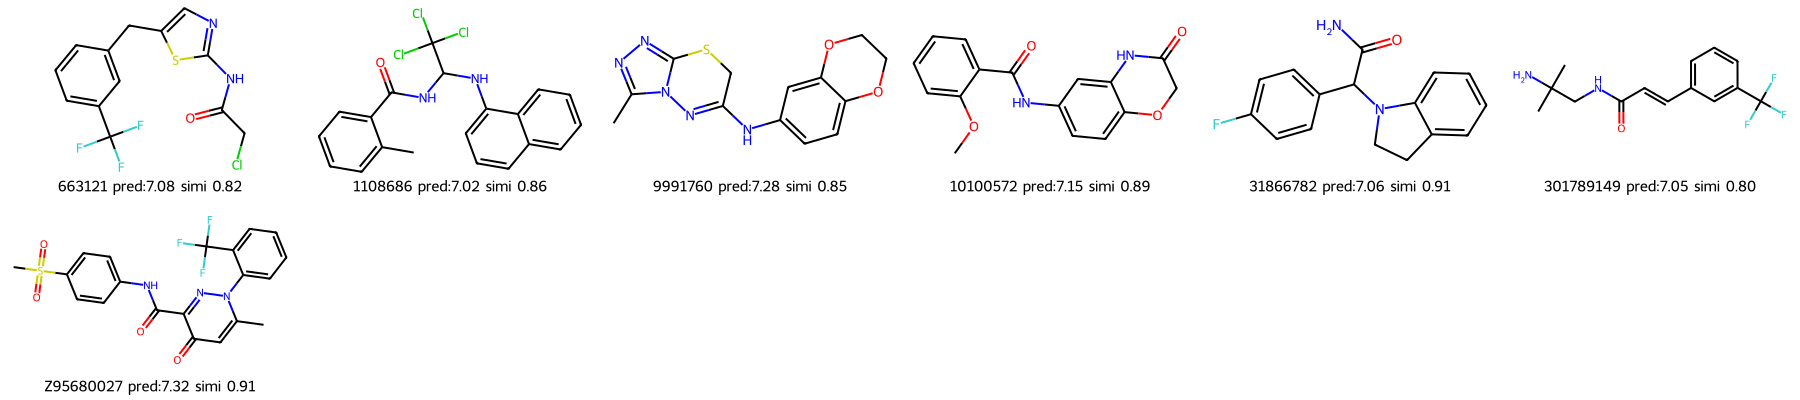

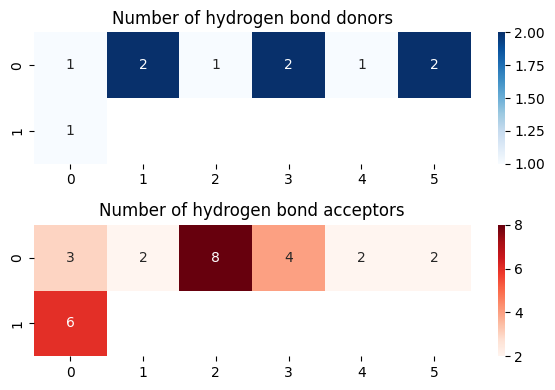

cluster: 3 n_molecules: 9


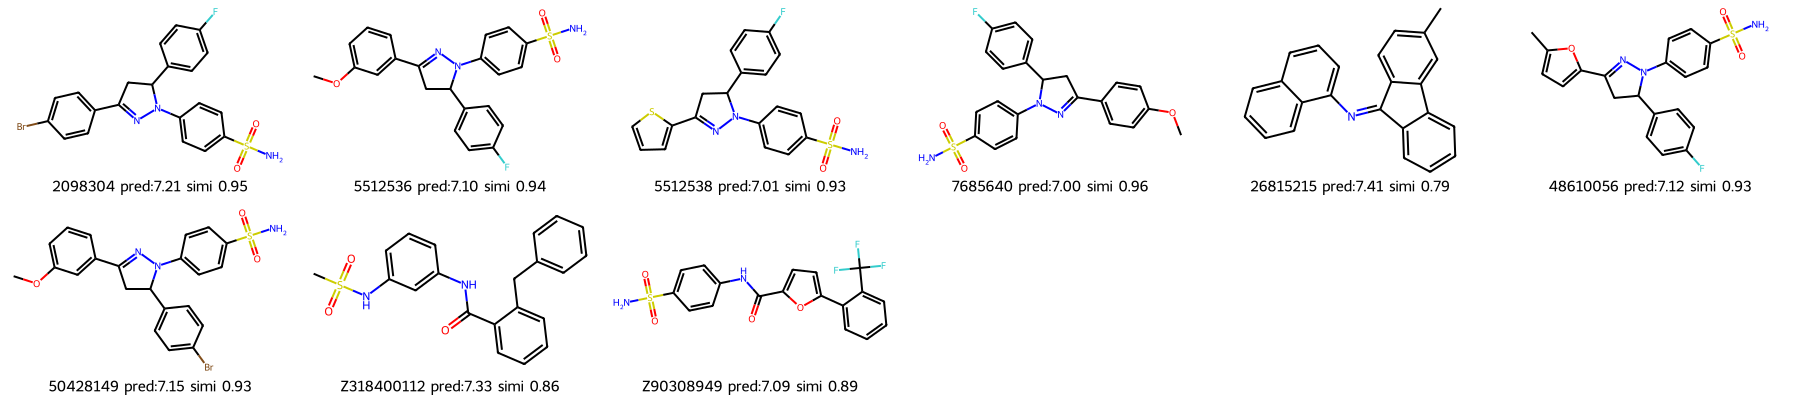

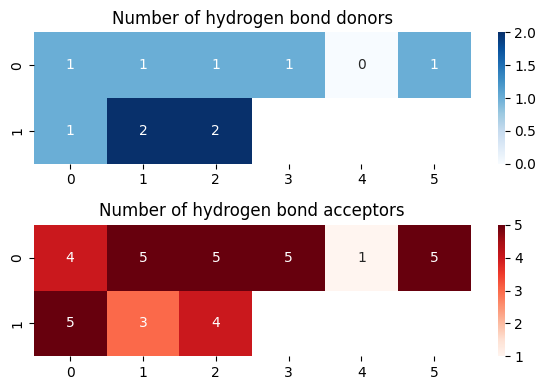

cluster: 4 n_molecules: 25


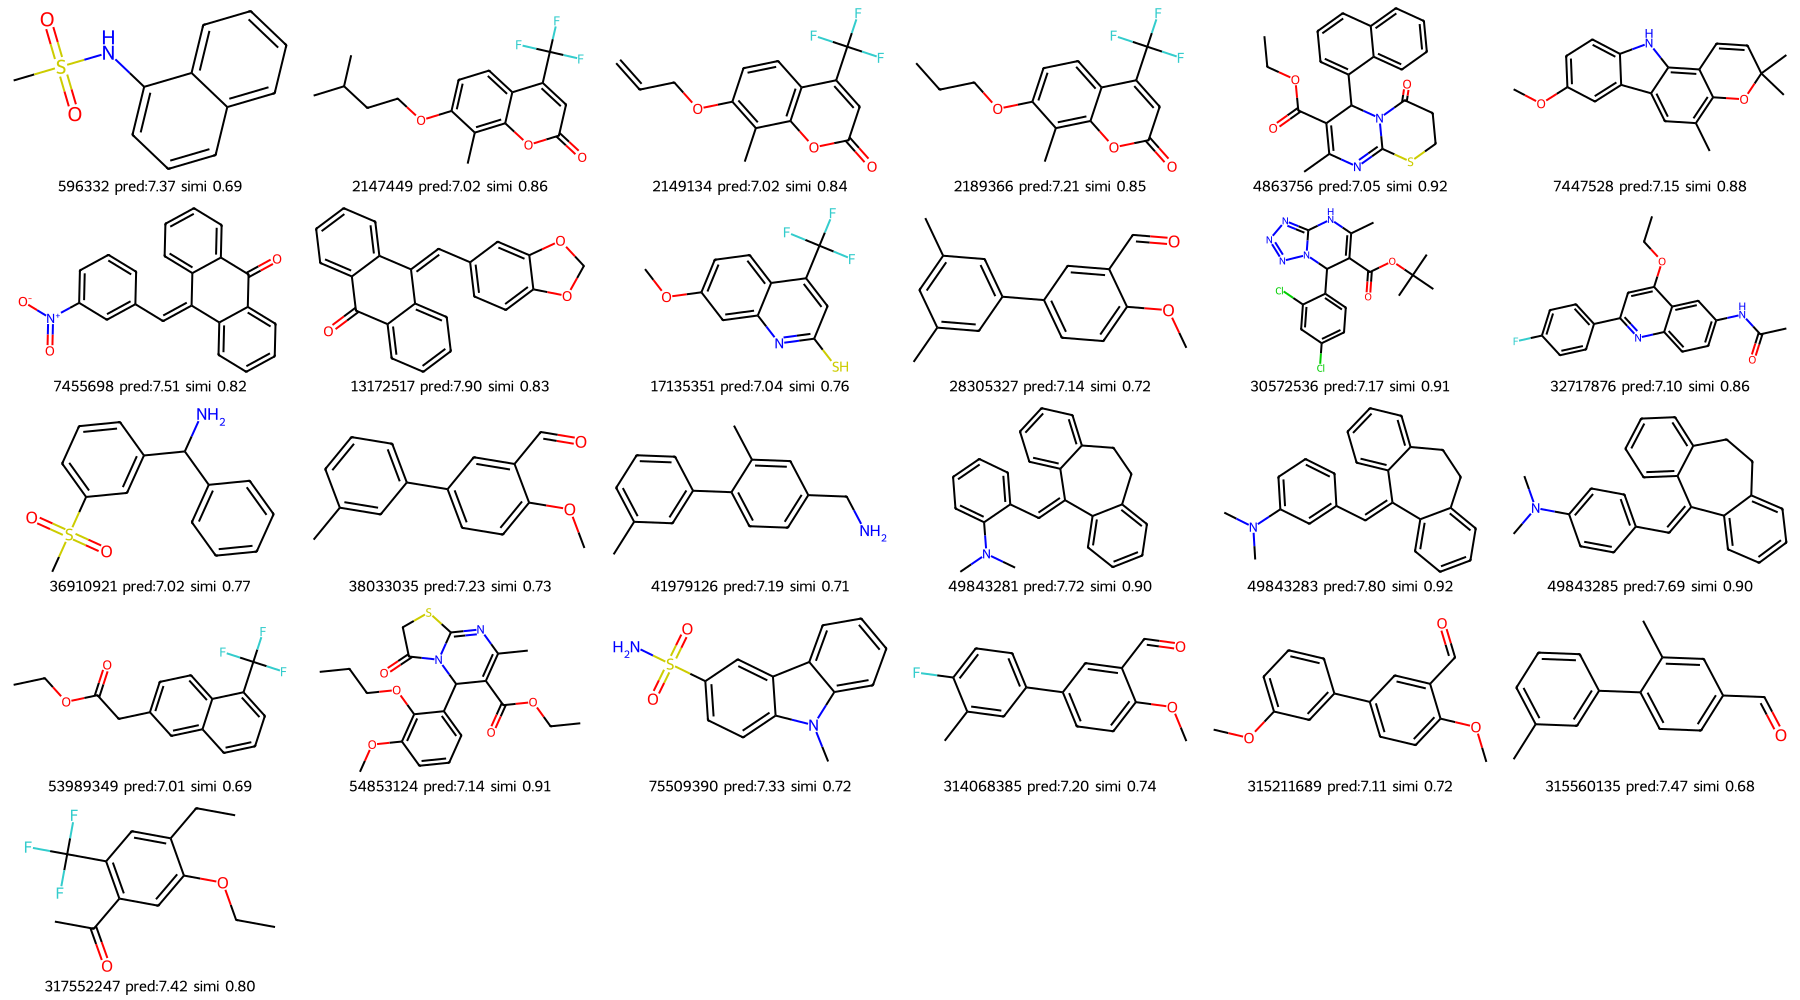

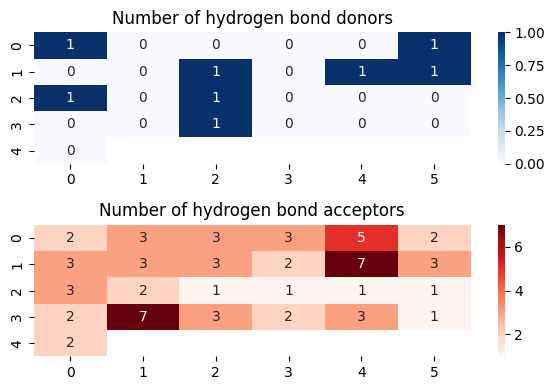

In [55]:
cluster_labels = clusterer.hierarchical_clustering(5, method="ward", criterion="maxclust")

plotter = MolGridPlotter(from_smi=True, size=(300, 200))

ncols = 6
for label in np.unique(cluster_labels):
    idxs = np.where(cluster_labels == label)[0]
    smiles = instock_nr3c2.supplier_smiles.iloc[idxs].tolist()
    labels = (
        instock_nr3c2.id.iloc[idxs]
        + " pred:"
        + instock_nr3c2.predictions.iloc[idxs].apply(lambda x: f"{x:.2f}")
        + " simi "
        + (1 - instock_nr3c2.nn_min.iloc[idxs]).apply(lambda x: f"{x:.2f}")
    )
    print("cluster:", label, "n_molecules:", len(idxs))
    img = plotter.mol_grid_png(
        mols=smiles,
        labels=labels,
        n_cols=ncols,
    )
    display(img)

    nrows = len(smiles) // ncols + 1 if len(smiles) % ncols != 0 else len(smiles) // ncols
    hbds = instock_nr3c2.iloc[idxs]["hbd"].tolist()
    hbas = instock_nr3c2.iloc[idxs]["hba"].tolist()
    if len(smiles) < ncols:
        fill_len = 0
        hbds = np.array(hbds + ([np.nan] * fill_len)).reshape(1, -1)
        hbas = np.array(hbas + ([np.nan] * fill_len)).reshape(1, -1)
    else:
        fill_len = ncols * nrows - len(smiles)
        hbds = np.array(hbds + ([np.nan] * fill_len)).reshape(nrows, ncols)
        hbas = np.array(hbas + ([np.nan] * fill_len)).reshape(nrows, ncols)
    fig, axs = plt.subplots(nrows=2, figsize=(ncols, 4))
    sns.heatmap(hbds, annot=True, ax=axs[0], cmap="Blues")
    axs[0].set_title("Number of hydrogen bond donors")
    sns.heatmap(hbas, annot=True, ax=axs[1], cmap="Reds")
    axs[1].set_title("Number of hydrogen bond acceptors")
    fig.tight_layout()
    plt.show()

# Selected molecules

In [56]:
adora_cpds = [
    "22755240",
    "1237561",
    "824745",
    "27070328",
    "1823372",
    "1249141",
]
minero_cpds = [
    "Z318400112",
    "Z90308949",
    "Z95680027",
]

screened_subset = pd.concat([instock_adora1, instock_nr3c2], ignore_index=True).query(
    "id in @adora_cpds | id in @minero_cpds"
)

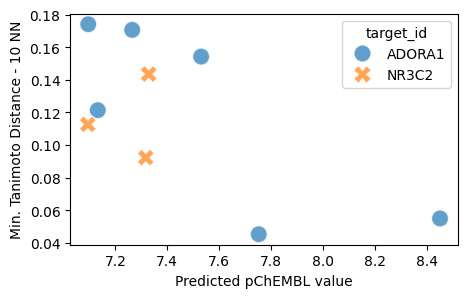

In [57]:
plt.subplots(figsize=(5, 3))

sns.scatterplot(
    data=screened_subset,
    x="predictions",
    y="nn_min",
    hue="target_id",
    style="target_id",
    alpha=0.7,
    s=150,
)

ax = plt.gca()
ax.set_ylabel("Min. Tanimoto Distance - 10 NN")
ax.set_xlabel("Predicted pChEMBL value")
plt.show()

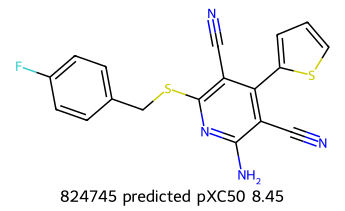

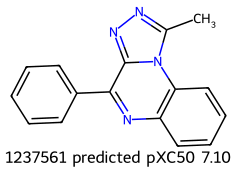

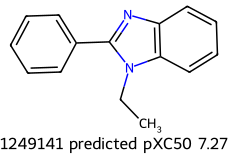

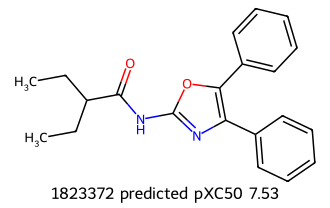

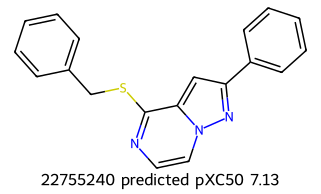

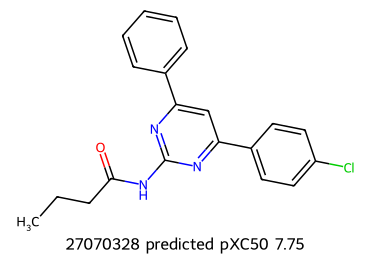

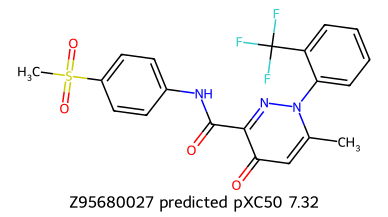

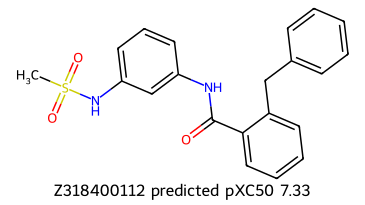

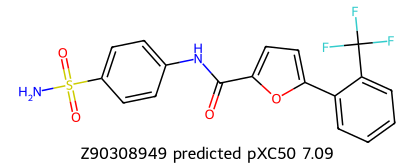

In [58]:
from chemFilters.img_render import MolGridPlotter

plotter = MolGridPlotter(
    from_smi=True, size=(-1, -1), bg_transparent=True, explicit_methyl=True, bond_line_width=1.5
)

screened_subset = screened_subset.assign(
    plot_label=lambda x: x["id"] + " predicted pXC50 " + x["predictions"].apply(lambda x: f"{x:.2f}")
)

for smi, label in zip(screened_subset.hitSmiles, screened_subset.plot_label):
    img = plotter.render_mol(smi, label=label)
    display(img)

In [59]:
plotter = MolGridPlotter(
    from_smi=True, size=(-1, -1), bg_transparent=True, explicit_methyl=True, bond_line_width=1.5
)

screened_subset = screened_subset.assign(
    plot_label=lambda x: x["id"] + " predicted pXC50 " + x["predictions"].apply(lambda x: f"{x:.2f}")
)

for smi, _id in zip(screened_subset.hitSmiles, screened_subset.id):
    img = plotter.render_ACS1996(smi, return_svg=True)
    with open(f"../figures/mol_structures/{_id}.svg", "w") as f:
        f.write(img)

In [60]:
for smi, _id in zip(screened_subset.nn_smiles, screened_subset.id):
    img = plotter.render_ACS1996(smi, return_svg=True)
    with open(f"../figures/mol_structures/nn_{_id}.svg", "w") as f:
        f.write(img)

In [62]:
from io import StringIO

stringo = StringIO()
screened_subset[["id", "predictions", "nn_min", "target_id"]].assign(
    Structure=lambda x: "![" + x.id + "](figures/mol_structures/" + x.id + ".svg)",
    NearestNeighborStructure=lambda x: "![" + x.id + "](figures/mol_structures/nn_" + x.id + ".svg)",
    predictions=lambda x: x.predictions.apply(lambda x: f"{x:.2f}"),
    nn_min=lambda x: x.nn_min.apply(lambda x: f"{x:.2f}"),
).rename(
    columns={
        "id": "Compound ID",
        "predictions": "Predicted pXC50",
        "nn_min": "Min. Tanimoto Distance - 10 NN",
        "target_id": "Target",
    }
)[
    [
        "Target",
        "Compound ID",
        "Structure",
        "Predicted pXC50",
        # "nn_min",
        # "NearestNeighborStructure",
    ]
].to_markdown(
    stringo, index=False
)
print(stringo.getvalue())

| Target   | Compound ID   | Structure                                            |   Predicted pXC50 |
|:---------|:--------------|:-----------------------------------------------------|------------------:|
| ADORA1   | 824745        | ![824745](figures/mol_structures/824745.svg)         |              8.45 |
| ADORA1   | 1237561       | ![1237561](figures/mol_structures/1237561.svg)       |              7.1  |
| ADORA1   | 1249141       | ![1249141](figures/mol_structures/1249141.svg)       |              7.27 |
| ADORA1   | 1823372       | ![1823372](figures/mol_structures/1823372.svg)       |              7.53 |
| ADORA1   | 22755240      | ![22755240](figures/mol_structures/22755240.svg)     |              7.13 |
| ADORA1   | 27070328      | ![27070328](figures/mol_structures/27070328.svg)     |              7.75 |
| NR3C2    | Z95680027     | ![Z95680027](figures/mol_structures/Z95680027.svg)   |              7.32 |
| NR3C2    | Z318400112    | ![Z318400112](figures/mol_structure